# Análisis de dataset FIFA
- Juan Pablo Mosquera
- David Zahid Riveros
- Oscar Manuel Contreras Gacha
- Anderson David Arenas Gutierrez

In [17]:
!pip install ydata_profiling
!pip install pandas-profiling

  Using cached pandas_profiling-3.2.0-py2.py3-none-any.whl.metadata (21 kB)
  Using cached joblib-1.1.1-py2.py3-none-any.whl.metadata (5.2 kB)
  Using cached MarkupSafe-2.1.5.tar.gz (19 kB)
  Preparing metadata (setup.py) ... done
  Using cached visions-0.7.4-py3-none-any.whl.metadata (5.9 kB)
  Using cached htmlmin-0.1.12.tar.gz (19 kB)
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [18]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from ydata_profiling import ProfileReport

# Scikit-Learn Preprocessing & Imputation
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, OneHotEncoder, MaxAbsScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.tree import plot_tree, export_text




# Scikit-Learn Models & Validation
from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, export_text
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.metrics import precision_score, recall_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score

# Configuración de Pandas y Semilla
pd.set_option("display.width", 110)
rng = np.random.default_rng(2026)
print("pandas", pd.__version__)

pandas 2.2.3


In [19]:
URL_DATASET = "https://raw.githubusercontent.com/Racsok/mineria/desarrollo/datasets/fifa_eda_stats.csv"

df = pd.read_csv(
    URL_DATASET,
    encoding="utf-8-sig",
    low_memory=False
)

print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

df.head()

Filas: 18207
Columnas: 57


,ID,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Preferred Foot,...,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Release Clause
0,158023,L. Messi,31,Argentina,94,94,FC Barcelona,€110.5M,€565K,Left,...,96.0,33.0,28.0,26.0,6.0,11.0,15.0,14.0,8.0,€226.5M
1,20801,Cristiano Ronaldo,33,Portugal,94,94,Juventus,€77M,€405K,Right,...,95.0,28.0,31.0,23.0,7.0,11.0,15.0,14.0,11.0,€127.1M
2,190871,Neymar Jr,26,Brazil,92,93,Paris Saint-Germain,€118.5M,€290K,Right,...,94.0,27.0,24.0,33.0,9.0,9.0,15.0,15.0,11.0,€228.1M
3,193080,De Gea,27,Spain,91,93,Manchester United,€72M,€260K,Right,...,68.0,15.0,21.0,13.0,90.0,85.0,87.0,88.0,94.0,€138.6M
4,192985,K. De Bruyne,27,Belgium,91,92,Manchester City,€102M,€355K,Right,...,88.0,68.0,58.0,51.0,15.0,13.0,5.0,10.0,13.0,€196.4M


## Dataset
El dataset trabaja sobre estadisticas numericas del rendimiento de jugadores de futbol dentro del FIFA, cuenta con 57 columnas y la columna objetivo sobre la cual se analizan los datos es el valor monetario de un jugador en el mercado.

link dataset: https://github.com/Racsok/mineria/blob/desarrollo/datasets/fifa_eda_stats.csv
            https://www.kaggle.com/datasets/mukeshmanral/fifa-data-for-eda-and-stats

# Perfilado y limpieza

Las columnas Value, Wage y Release Clause vienen como strings con formato tipo "€110.5M", "€565K" o "€0". Esto impide cualquier operación estadística (correlación, media, escalado) porque pandas las trata como texto. La función convert_value_to_numeric:
Devuelve None si el valor es nulo o no es string (control defensivo).

* Elimina el símbolo € y espacios.
* Si contiene 'M', multiplica el número por 1 000 000 (millones).
* Si contiene 'K', multiplica por 1 000 (miles).
* Si es exactamente "0", devuelve 0.0.
* En cualquier otro caso intenta convertirlo a float; si falla, devuelve None.

In [20]:
"""Limpieza de valores de dinero"""
def convert_value_to_numeric(value_str):
    if pd.isna(value_str) or not isinstance(value_str, str):
        return None
    value_str = value_str.replace('€', '').strip()
    if 'M' in value_str:
        return float(value_str.replace('M', '')) * 1_000_000
    elif 'K' in value_str:
        return float(value_str.replace('K', '')) * 1_000
    elif value_str == '0':
        return 0.0
    else:
        try:
            return float(value_str)
        except ValueError:
            return None
df['Value'] = df['Value'].apply(convert_value_to_numeric)
df['Wage'] = df['Wage'].apply(convert_value_to_numeric)
df['Release Clause'] = df['Release Clause'].apply(convert_value_to_numeric)

In [21]:
print(df["Value"].value_counts(normalize=True).round(3))

Value
1100000.0     0.024
375000.0      0.020
425000.0      0.019
325000.0      0.019
450000.0      0.019
              ...  
63000000.0    0.000
51500000.0    0.000
53500000.0    0.000
58000000.0    0.000
81000000.0    0.000
Name: proportion, Length: 217, dtype: float64


## Perfilado

Se Ejecuta la función de perfilado que recorre todas las columnas del DataFrame y devuelve una tabla resumen con:

* tipo: el dtype de la columna (útil para detectar numéricas disfrazadas de texto).
* distintos: número de valores únicos (nunique), para medir cardinalidad.
* faltan_%: porcentaje de nulos (isna().mean() * 100), redondeado a 1 decimal.
* moda: el valor más frecuente (s.mode().iloc[0]), con control por si la columna está vacía.
* Para columnas numéricas, además: min, mediana, media y max.

Finalmente se hace set_index("columna") para que cada fila quede identificada por el nombre de la variable. Este perfil es clave porque expone de un vistazo tres problemas: la columna Loaned From con 93.1 % de nulos, Height y Weight guardadas como strings, y Release Clause con 8.6 % de faltantes.

In [22]:
def perfilar(df):
    filas = []
    for col in df.columns:
        s = df[col]
        fila = {
            "columna":   col,
            "tipo":      str(s.dtype),
            "distintos": s.nunique(),
            "faltan_%":  round(s.isna().mean() * 100, 1),
            "moda":      s.mode().iloc[0] if not s.mode().empty else None,
        }
        if pd.api.types.is_numeric_dtype(s):
            fila["min"]     = round(s.min(), 2)
            fila["mediana"] = round(s.median(), 2)
            fila["media"]   = round(s.mean(), 2)
            fila["max"]     = round(s.max(), 2)
        filas.append(fila)
    return pd.DataFrame(filas).set_index("columna")

perfilar(df)


,tipo,distintos,faltan_%,moda,min,mediana,media,max
columna,,,,,,,,
ID,int64,18207,0.0,16,16.0,221759.0,214298.34,246620.0
Name,object,17194,0.0,J. Rodríguez,NaN,NaN,NaN,NaN
Age,int64,29,0.0,21,16.0,25.0,25.12,45.0
Nationality,object,164,0.0,England,NaN,NaN,NaN,NaN
Overall,int64,48,0.0,66,46.0,66.0,66.24,94.0
Potential,int64,47,0.0,70,48.0,71.0,71.31,95.0
Club,object,651,1.3,AS Monaco,NaN,NaN,NaN,NaN
Value,float64,217,0.0,1100000.0,0.0,675000.0,2410695.89,118500000.0
Wage,float64,144,0.0,1000.0,0.0,3000.0,9731.31,565000.0


<div id="df-812bf6ae-a487-4752-ad77-2c6b21f068fc" class="colab-df-container">
    <div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>tipo</th>
      <th>distintos</th>
      <th>faltan_%</th>
      <th>moda</th>
      <th>min</th>
      <th>mediana</th>
      <th>media</th>
      <th>max</th>
    </tr>
    <tr>
      <th>columna</th>
      <th></th>
      <th></th>
      <th></th>
      <th></th>
      <th></th>
      <th></th>
      <th></th>
      <th></th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>ID</th>
      <td>int64</td>
      <td>18207</td>
      <td>0.0</td>
      <td>16</td>
      <td>16.0</td>
      <td>221759.0</td>
      <td>214298.34</td>
      <td>246620.0</td>
    </tr>
    <tr>
      <th>Name</th>
      <td>object</td>
      <td>17194</td>
      <td>0.0</td>
      <td>J. Rodríguez</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
    </tr>
    <tr>
      <th>Age</th>
      <td>int64</td>
      <td>29</td>
      <td>0.0</td>
      <td>21</td>
      <td>16.0</td>
      <td>25.0</td>
      <td>25.12</td>
      <td>45.0</td>
    </tr>
    <tr>
      <th>Nationality</th>
      <td>object</td>
      <td>164</td>
      <td>0.0</td>
      <td>England</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
    </tr>
    <tr>
      <th>Overall</th>
      <td>int64</td>
      <td>48</td>
      <td>0.0</td>
      <td>66</td>
      <td>46.0</td>
      <td>66.0</td>
      <td>66.24</td>
      <td>94.0</td>
    </tr>
    <tr>
      <th>Potential</th>
      <td>int64</td>
      <td>47</td>
      <td>0.0</td>
      <td>70</td>
      <td>48.0</td>
      <td>71.0</td>
      <td>71.31</td>
      <td>95.0</td>
    </tr>
    <tr>
      <th>Club</th>
      <td>object</td>
      <td>651</td>
      <td>1.3</td>
      <td>AS Monaco</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
    </tr>
    <tr>
      <th>Value</th>
      <td>object</td>
      <td>217</td>
      <td>0.0</td>
      <td>€1.1M</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
    </tr>
    <tr>
      <th>Wage</th>
      <td>object</td>
      <td>144</td>
      <td>0.0</td>
      <td>€1K</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
    </tr>
    <tr>
      <th>Preferred Foot</th>
      <td>object</td>
      <td>2</td>
      <td>0.3</td>
      <td>Right</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
    </tr>
    <tr>
      <th>International Reputation</th>
      <td>float64</td>
      <td>5</td>
      <td>0.3</td>
      <td>1.0</td>
      <td>1.0</td>
      <td>1.0</td>
      <td>1.11</td>
      <td>5.0</td>
    </tr>
    <tr>
      <th>Weak Foot</th>
      <td>float64</td>
      <td>5</td>
      <td>0.3</td>
      <td>3.0</td>
      <td>1.0</td>
      <td>3.0</td>
      <td>2.95</td>
      <td>5.0</td>
    </tr>
    <tr>
      <th>Skill Moves</th>
      <td>float64</td>
      <td>5</td>
      <td>0.3</td>
      <td>2.0</td>
      <td>1.0</td>
      <td>2.0</td>
      <td>2.36</td>
      <td>5.0</td>
    </tr>
    <tr>
      <th>Work Rate</th>
      <td>object</td>
      <td>9</td>
      <td>0.3</td>
      <td>Medium/ Medium</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
    </tr>
    <tr>
      <th>Body Type</th>
      <td>object</td>
      <td>10</td>
      <td>0.3</td>
      <td>Normal</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
    </tr>
    <tr>
      <th>Position</th>
      <td>object</td>
      <td>27</td>
      <td>0.3</td>
      <td>ST</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
    </tr>
    <tr>
      <th>Jersey Number</th>
      <td>float64</td>
      <td>99</td>
      <td>0.3</td>
      <td>8.0</td>
      <td>1.0</td>
      <td>17.0</td>
      <td>19.55</td>
      <td>99.0</td>
    </tr>
    <tr>
      <th>Joined</th>
      <td>object</td>
      <td>1736</td>
      <td>8.5</td>
      <td>Jul 1, 2018</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
    </tr>
    <tr>
      <th>Loaned From</th>
      <td>object</td>
      <td>341</td>
      <td>93.1</td>
      <td>Atalanta</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
    </tr>
    <tr>
      <th>Contract Valid Until</th>
      <td>object</td>
      <td>36</td>
      <td>1.6</td>
      <td>2019</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
    </tr>
    <tr>
      <th>Height</th>
      <td>object</td>
      <td>21</td>
      <td>0.3</td>
      <td>6'0</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
    </tr>
    <tr>
      <th>Weight</th>
      <td>object</td>
      <td>57</td>
      <td>0.3</td>
      <td>165lbs</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
    </tr>
    <tr>
      <th>Crossing</th>
      <td>float64</td>
      <td>89</td>
      <td>0.3</td>
      <td>62.0</td>
      <td>5.0</td>
      <td>54.0</td>
      <td>49.73</td>
      <td>93.0</td>
    </tr>
    <tr>
      <th>Finishing</th>
      <td>float64</td>
      <td>93</td>
      <td>0.3</td>
      <td>58.0</td>
      <td>2.0</td>
      <td>49.0</td>
      <td>45.55</td>
      <td>95.0</td>
    </tr>
    <tr>
      <th>HeadingAccuracy</th>
      <td>float64</td>
      <td>91</td>
      <td>0.3</td>
      <td>58.0</td>
      <td>4.0</td>
      <td>56.0</td>
      <td>52.30</td>
      <td>94.0</td>
    </tr>
    <tr>
      <th>ShortPassing</th>
      <td>float64</td>
      <td>85</td>
      <td>0.3</td>
      <td>64.0</td>
      <td>7.0</td>
      <td>62.0</td>
      <td>58.69</td>
      <td>93.0</td>
    </tr>
    <tr>
      <th>Volleys</th>
      <td>float64</td>
      <td>87</td>
      <td>0.3</td>
      <td>49.0</td>
      <td>4.0</td>
      <td>44.0</td>
      <td>42.91</td>
      <td>90.0</td>
    </tr>
    <tr>
      <th>Dribbling</th>
      <td>float64</td>
      <td>94</td>
      <td>0.3</td>
      <td>64.0</td>
      <td>4.0</td>
      <td>61.0</td>
      <td>55.37</td>
      <td>97.0</td>
    </tr>
    <tr>
      <th>Curve</th>
      <td>float64</td>
      <td>89</td>
      <td>0.3</td>
      <td>58.0</td>
      <td>6.0</td>
      <td>48.0</td>
      <td>47.17</td>
      <td>94.0</td>
    </tr>
    <tr>
      <th>FKAccuracy</th>
      <td>float64</td>
      <td>90</td>
      <td>0.3</td>
      <td>42.0</td>
      <td>3.0</td>
      <td>41.0</td>
      <td>42.86</td>
      <td>94.0</td>
    </tr>
    <tr>
      <th>LongPassing</th>
      <td>float64</td>
      <td>84</td>
      <td>0.3</td>
      <td>62.0</td>
      <td>9.0</td>
      <td>56.0</td>
      <td>52.71</td>
      <td>93.0</td>
    </tr>
    <tr>
      <th>BallControl</th>
      <td>float64</td>
      <td>90</td>
      <td>0.3</td>
      <td>65.0</td>
      <td>5.0</td>
      <td>63.0</td>
      <td>58.37</td>
      <td>96.0</td>
    </tr>
    <tr>
      <th>Acceleration</th>
      <td>float64</td>
      <td>86</td>
      <td>0.3</td>
      <td>69.0</td>
      <td>12.0</td>
      <td>67.0</td>
      <td>64.61</td>
      <td>97.0</td>
    </tr>
    <tr>
      <th>SprintSpeed</th>
      <td>float64</td>
      <td>85</td>
      <td>0.3</td>
      <td>68.0</td>
      <td>12.0</td>
      <td>67.0</td>
      <td>64.73</td>
      <td>96.0</td>
    </tr>
    <tr>
      <th>Agility</th>
      <td>float64</td>
      <td>81</td>
      <td>0.3</td>
      <td>68.0</td>
      <td>14.0</td>
      <td>66.0</td>
      <td>63.50</td>
      <td>96.0</td>
    </tr>
    <tr>
      <th>Reactions</th>
      <td>float64</td>
      <td>68</td>
      <td>0.3</td>
      <td>65.0</td>
      <td>21.0</td>
      <td>62.0</td>
      <td>61.84</td>
      <td>96.0</td>
    </tr>
    <tr>
      <th>Balance</th>
      <td>float64</td>
      <td>81</td>
      <td>0.3</td>
      <td>68.0</td>
      <td>16.0</td>
      <td>66.0</td>
      <td>63.97</td>
      <td>96.0</td>
    </tr>
    <tr>
      <th>ShotPower</th>
      <td>float64</td>
      <td>92</td>
      <td>0.3</td>
      <td>68.0</td>
      <td>2.0</td>
      <td>59.0</td>
      <td>55.46</td>
      <td>95.0</td>
    </tr>
    <tr>
      <th>Jumping</th>
      <td>float64</td>
      <td>74</td>
      <td>0.3</td>
      <td>70.0</td>
      <td>15.0</td>
      <td>66.0</td>
      <td>65.09</td>
      <td>95.0</td>
    </tr>
    <tr>
      <th>Stamina</th>
      <td>float64</td>
      <td>85</td>
      <td>0.3</td>
      <td>68.0</td>
      <td>12.0</td>
      <td>66.0</td>
      <td>63.22</td>
      <td>96.0</td>
    </tr>
    <tr>
      <th>Strength</th>
      <td>float64</td>
      <td>74</td>
      <td>0.3</td>
      <td>68.0</td>
      <td>17.0</td>
      <td>67.0</td>
      <td>65.31</td>
      <td>97.0</td>
    </tr>
    <tr>
      <th>LongShots</th>
      <td>float64</td>
      <td>92</td>
      <td>0.3</td>
      <td>59.0</td>
      <td>3.0</td>
      <td>51.0</td>
      <td>47.11</td>
      <td>94.0</td>
    </tr>
    <tr>
      <th>Aggression</th>
      <td>float64</td>
      <td>85</td>
      <td>0.3</td>
      <td>65.0</td>
      <td>11.0</td>
      <td>59.0</td>
      <td>55.87</td>
      <td>95.0</td>
    </tr>
    <tr>
      <th>Interceptions</th>
      <td>float64</td>
      <td>89</td>
      <td>0.3</td>
      <td>62.0</td>
      <td>3.0</td>
      <td>52.0</td>
      <td>46.70</td>
      <td>92.0</td>
    </tr>
    <tr>
      <th>Positioning</th>
      <td>float64</td>
      <td>94</td>
      <td>0.3</td>
      <td>58.0</td>
      <td>2.0</td>
      <td>55.0</td>
      <td>49.96</td>
      <td>95.0</td>
    </tr>
    <tr>
      <th>Vision</th>
      <td>float64</td>
      <td>85</td>
      <td>0.3</td>
      <td>58.0</td>
      <td>10.0</td>
      <td>55.0</td>
      <td>53.40</td>
      <td>94.0</td>
    </tr>
    <tr>
      <th>Penalties</th>
      <td>float64</td>
      <td>87</td>
      <td>0.3</td>
      <td>45.0</td>
      <td>5.0</td>
      <td>49.0</td>
      <td>48.55</td>
      <td>92.0</td>
    </tr>
    <tr>
      <th>Composure</th>
      <td>float64</td>
      <td>84</td>
      <td>0.3</td>
      <td>60.0</td>
      <td>3.0</td>
      <td>60.0</td>
      <td>58.65</td>
      <td>96.0</td>
    </tr>
    <tr>
      <th>Marking</th>
      <td>float64</td>
      <td>92</td>
      <td>0.3</td>
      <td>60.0</td>
      <td>3.0</td>
      <td>53.0</td>
      <td>47.28</td>
      <td>94.0</td>
    </tr>
    <tr>
      <th>StandingTackle</th>
      <td>float64</td>
      <td>90</td>
      <td>0.3</td>
      <td>66.0</td>
      <td>2.0</td>
      <td>55.0</td>
      <td>47.70</td>
      <td>93.0</td>
    </tr>
    <tr>
      <th>SlidingTackle</th>
      <td>float64</td>
      <td>88</td>
      <td>0.3</td>
      <td>62.0</td>
      <td>3.0</td>
      <td>52.0</td>
      <td>45.66</td>
      <td>91.0</td>
    </tr>
    <tr>
      <th>GKDiving</th>
      <td>float64</td>
      <td>71</td>
      <td>0.3</td>
      <td>8.0</td>
      <td>1.0</td>
      <td>11.0</td>
      <td>16.62</td>
      <td>90.0</td>
    </tr>
    <tr>
      <th>GKHandling</th>
      <td>float64</td>
      <td>70</td>
      <td>0.3</td>
      <td>10.0</td>
      <td>1.0</td>
      <td>11.0</td>
      <td>16.39</td>
      <td>92.0</td>
    </tr>
    <tr>
      <th>GKKicking</th>
      <td>float64</td>
      <td>79</td>
      <td>0.3</td>
      <td>12.0</td>
      <td>1.0</td>
      <td>11.0</td>
      <td>16.23</td>
      <td>91.0</td>
    </tr>
    <tr>
      <th>GKPositioning</th>
      <td>float64</td>
      <td>79</td>
      <td>0.3</td>
      <td>10.0</td>
      <td>1.0</td>
      <td>11.0</td>
      <td>16.39</td>
      <td>90.0</td>
    </tr>
    <tr>
      <th>GKReflexes</th>
      <td>float64</td>
      <td>76</td>
      <td>0.3</td>
      <td>10.0</td>
      <td>1.0</td>
      <td>11.0</td>
      <td>16.71</td>
      <td>94.0</td>
    </tr>
    <tr>
      <th>Release Clause</th>
      <td>object</td>
      <td>1244</td>
      <td>8.6</td>
      <td>€1.1M</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
    </tr>
  </tbody>
</table>
</div>
    <div class="colab-df-buttons">
      
  <div class="colab-df-container">
    <button class="colab-df-convert" onclick="convertToInteractive('df-812bf6ae-a487-4752-ad77-2c6b21f068fc')"
            title="Convert this dataframe to an interactive table."
            style="display:none;">
      
  <svg xmlns="http://www.w3.org/2000/svg" height="24px" viewBox="0 -960 960 960">
    <path d="M120-120v-720h720v720H120Zm60-500h600v-160H180v160Zm220 220h160v-160H400v160Zm0 220h160v-160H400v160ZM180-400h160v-160H180v160Zm440 0h160v-160H620v160ZM180-180h160v-160H180v160Zm440 0h160v-160H620v160Z"/>
  </svg>
    </button>
    
  <style>
    .colab-df-container {
      display:flex;
      gap: 12px;
    }

    .colab-df-convert {
      background-color: #E8F0FE;
      border: none;
      border-radius: 50%;
      cursor: pointer;
      display: none;
      fill: #1967D2;
      height: 32px;
      padding: 0 0 0 0;
      width: 32px;
    }

    .colab-df-convert:hover {
      background-color: #E2EBFA;
      box-shadow: 0px 1px 2px rgba(60, 64, 67, 0.3), 0px 1px 3px 1px rgba(60, 64, 67, 0.15);
      fill: #174EA6;
    }

    .colab-df-buttons div {
      margin-bottom: 4px;
    }

    [theme=dark] .colab-df-convert {
      background-color: #3B4455;
      fill: #D2E3FC;
    }

    [theme=dark] .colab-df-convert:hover {
      background-color: #434B5C;
      box-shadow: 0px 1px 3px 1px rgba(0, 0, 0, 0.15);
      filter: drop-shadow(0px 1px 2px rgba(0, 0, 0, 0.3));
      fill: #FFFFFF;
    }
  </style>
  </div>
  
  </div>

## Tres problemas encontrados y su solución

* **`Loaned From` con 93.1% de datos nulos:**  
  La gran mayoría de jugadores no están cedidos a préstamo, lo que genera una columna desierta de casi solo faltantes.  
  * **Solución:** Eliminar la columna por falta de varianza o convertirla en una bandera binaria `is_loaned` (1 si tiene club de origen, 0 si es `NaN`).

* **Valores numéricos guardados como texto (`Height` y `Weight`):**  
  Tienen formato de cadena tipo `6'0` y `165lbs`, lo que impide su análisis estadístico y cálculo de correlación directa.  
  * **Solución:** Aplicar una función de transformación en Pandas para convertir `Height` a centímetros y `Weight` a kilogramos (o libras numéricas) y castearlas a tipo `float64`.

* **Nulos masivos en cláusula de rescisión (`Release Clause` con 8.6% de faltantes):**  
  Existen 1,564 jugadores sin cláusula asignada en la base de datos.  
  * **Solución:** Imputar los faltantes calculando una estimación basada en la relación proporcional entre `Value` y `Overall`, o asignar 0 si el contrato no contempla dicha cláusula.

---

## Columnas objetivo y su reparto

###Numerica Value
Al ser **`Value`** una variable continua económica (target de regresión), el método `value_counts(normalize=True)` se utiliza para observar la concentración del mercado o agrupar por rangos. Su reparto estadístico directo muestra:

* **Mínimo:** €0.0
* **Mediana:** €675,000.0
* **Media:** €2,410,695.89
* **Máximo:** €118,500,000.0

*(El reparto de `Value` presenta un marcado sesgo positivo a la derecha [right-skewed], donde más del 50% de los jugadores tiene un valor de mercado inferior a €675,000, mientras que una élite de superestrellas eleva la media a €2.4M y alcanza un pico de €118.5M).*

### Categorica position
Usaremos las variables carateristicas del jufador para oredecir que posicion e jugara



## Limpieza y arreglos

### Solución al Problema 1: Columna `Loaned From` con valores nulos

Se crea una nueva columna `is_loaned` que indica si el jugador está cedido (1) o no (0). Posteriormente, se elimina la columna original `Loaned From`.

In [23]:
# Crear la columna binaria 'is_loaned': 1 si el jugador está cedido (no es NaN en 'Loaned From'), 0 en caso contrario.
df['is_loaned'] = df['Loaned From'].notna().astype(int)

# Eliminar la columna original 'Loaned From' ya que la nueva columna captura la información relevante.
df = df.drop(columns=['Loaned From'])

# Mostrar las primeras filas del DataFrame con la nueva columna y la columna eliminada
display(df[['Name', 'Club', 'is_loaned']].head())

# Verificar el tipo de datos y la ausencia de la columna original
print(df[['is_loaned']].info())

,Name,Club,is_loaned
0,L. Messi,FC Barcelona,0
1,Cristiano Ronaldo,Juventus,0
2,Neymar Jr,Paris Saint-Germain,0
3,De Gea,Manchester United,0
4,K. De Bruyne,Manchester City,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18207 entries, 0 to 18206
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   is_loaned  18207 non-null  int64
dtypes: int64(1)
memory usage: 142.4 KB
None


### Solución al Problema 2: Valores numéricos guardados como texto (`Height` y `Weight`)

Se convierten las columnas `Height` y `Weight` de formato texto a numérico. Para `Height`, se convierte de pies y pulgadas a centímetros. Para `Weight`, se elimina la unidad 'lbs' y se convierte a float.

In [24]:
# Función para convertir altura de pies'pulgadas a centímetros
def convert_height_to_cm(height_str):
    if pd.isna(height_str) or not isinstance(height_str, str):
        return None
    try:
        feet, inches = map(int, height_str.replace('"', '').split("'"))
        return (feet * 30.48) + (inches * 2.54)
    except ValueError:
        return None

# Función para convertir peso de 'Xlbs' a un valor numérico en libras
def convert_weight_to_lbs(weight_str):
    if pd.isna(weight_str) or not isinstance(weight_str, str):
        return None
    try:
        return float(weight_str.replace('lbs', ''))
    except ValueError:
        return None

# Aplicar las funciones de conversión a las columnas 'Height' y 'Weight'
df['Height_cm'] = df['Height'].apply(convert_height_to_cm)
df['Weight_lbs'] = df['Weight'].apply(convert_weight_to_lbs)

# Eliminar las columnas originales 'Height' y 'Weight' si ya no son necesarias
df = df.drop(columns=['Height', 'Weight'])

# Mostrar las primeras filas del DataFrame con las nuevas columnas y las columnas eliminadas
display(df[['Name', 'Height_cm', 'Weight_lbs']].head())

# Verificar el tipo de datos de las nuevas columnas
print(df[['Height_cm', 'Weight_lbs']].info())

,Name,Height_cm,Weight_lbs
0,L. Messi,170.18,159.0
1,Cristiano Ronaldo,187.96,183.0
2,Neymar Jr,175.26,150.0
3,De Gea,193.04,168.0
4,K. De Bruyne,180.34,154.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18207 entries, 0 to 18206
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Height_cm   18159 non-null  float64
 1   Weight_lbs  18159 non-null  float64
dtypes: float64(2)
memory usage: 284.6 KB
None


### Solución al Problema 3: Nulos en la columna `Release Clause`

Release Clause tenía 1 564 valores nulos (8.6 %). La decisión de negocio adoptada es que un nulo significa que el jugador no tiene cláusula de rescisión, lo cual es perfectamente válido en el mundo real. Por eso se imputa con 0 en lugar de con media o mediana: imputar con la media inventaría un contrato que no existe y distorsionaría la distribución; imputar con 0 preserva el significado real ("sin cláusula"). Se verifica con isnull().sum() que ya no queden nulos y con df.info() que el tipo siga siendo float64.

In [25]:
# Imputar los valores nulos en 'Release Clause' con 0
df['Release Clause'] = df['Release Clause'].fillna(0)

# Verificar el número de valores nulos después de la imputación
print(f"Valores nulos en 'Release Clause' después de la imputación: {df['Release Clause'].isnull().sum()}")

# Mostrar una descripción estadística de la columna 'Release Clause' para verificar los cambios
display(df[['Name', 'Club', 'Value', 'Release Clause']].head())

# Verificar el tipo de datos de la columna 'Release Clause'
print(df[['Release Clause']].info())

Valores nulos en 'Release Clause' después de la imputación: 0


,Name,Club,Value,Release Clause
0,L. Messi,FC Barcelona,110500000.0,226500000.0
1,Cristiano Ronaldo,Juventus,77000000.0,127100000.0
2,Neymar Jr,Paris Saint-Germain,118500000.0,228100000.0
3,De Gea,Manchester United,72000000.0,138600000.0
4,K. De Bruyne,Manchester City,102000000.0,196400000.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18207 entries, 0 to 18206
Data columns (total 1 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Release Clause  18207 non-null  float64
dtypes: float64(1)
memory usage: 142.4 KB
None


## Descripcion

In [26]:
df.describe()

,ID,Age,Overall,Potential,Value,Wage,International Reputation,Weak Foot,Skill Moves,Jersey Number,...,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Release Clause,is_loaned,Height_cm,Weight_lbs
count,18207.000000,18207.000000,18207.000000,18207.000000,1.820700e+04,18207.000000,18159.000000,18159.000000,18159.000000,18147.000000,...,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,1.820700e+04,18207.000000,18159.000000,18159.000000
mean,214298.338606,25.122206,66.238699,71.307299,2.410696e+06,9731.312133,1.113222,2.947299,2.361308,19.546096,...,45.661435,16.616223,16.391596,16.232061,16.388898,16.710887,4.191200e+06,0.069424,181.257584,165.979129
std,29965.244204,4.669943,6.908930,6.136496,5.594933e+06,21999.290406,0.394031,0.660456,0.756164,15.947765,...,21.289135,17.695349,16.906900,16.502864,17.034669,17.955119,1.070778e+07,0.254180,6.730145,15.593344
min,16.000000,16.000000,46.000000,48.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,1.000000,...,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000e+00,0.000000,154.940000,110.000000
25%,200315.500000,21.000000,62.000000,67.000000,3.000000e+05,1000.000000,1.000000,3.000000,2.000000,8.000000,...,24.000000,8.000000,8.000000,8.000000,8.000000,8.000000,3.920000e+05,0.000000,175.260000,154.000000
50%,221759.000000,25.000000,66.000000,71.000000,6.750000e+05,3000.000000,1.000000,3.000000,2.000000,17.000000,...,52.000000,11.000000,11.000000,11.000000,11.000000,11.000000,1.000000e+06,0.000000,180.340000,165.000000
75%,236529.500000,28.000000,71.000000,75.000000,2.000000e+06,9000.000000,1.000000,3.000000,3.000000,26.000000,...,64.000000,14.000000,14.000000,14.000000,14.000000,14.000000,3.000000e+06,0.000000,185.420000,176.000000
max,246620.000000,45.000000,94.000000,95.000000,1.185000e+08,565000.000000,5.000000,5.000000,5.000000,99.000000,...,91.000000,90.000000,92.000000,91.000000,90.000000,94.000000,2.281000e+08,1.000000,205.740000,243.000000


## Imputación de los datos
Muchas columnas presentan exactamente la misma cantidad de nulos, por lo que se procede a mirar la cantidad de jugadores con nulos en todas estas variables, y borrarlos ya que no aportan ningun valor.

Los Nulos en variables como club, joined, y contract valid until, tienen sentido en el negocio ya que un jugador sin club no tiene contrato, y es valido, se reemplazan los nulos por sin club y no disponible, para los jugadores sin jersey se deja un -1

### "Height_cm", "Weight_lbs", "Crossing"


In [27]:
columnas_principales = [
    "Height_cm", "Weight_lbs", "Crossing"
]

columnas_disponibles = [
    columna for columna in columnas_principales
    if columna in df.columns
]

filas_vacias_principales = df[columnas_disponibles].isna().all(axis=1)
display(df.loc[filas_vacias_principales].head(10))

,ID,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Preferred Foot,...,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Release Clause,is_loaned,Height_cm,Weight_lbs
13236,177971,J. McNulty,33,Scotland,62,62,Rochdale,120000.0,1000.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,NaN,NaN
13237,195380,J. Barrera,29,Nicaragua,62,62,Boyacá Chicó FC,300000.0,1000.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,NaN,NaN
13238,139317,J. Stead,35,England,62,62,Notts County,140000.0,3000.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,NaN,NaN
13239,240437,A. Semprini,20,Italy,62,72,Brescia,425000.0,1000.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,NaN,NaN
13240,209462,R. Bingham,24,England,62,66,Hamilton Academical FC,400000.0,1000.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,NaN,NaN
13241,219702,K. Dankowski,21,Poland,62,72,Śląsk Wrocław,425000.0,1000.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,NaN,NaN
13242,225590,I. Colman,23,Argentina,62,70,Club Atlético Aldosivi,450000.0,2000.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,NaN,NaN
13243,233782,M. Feeney,19,England,62,78,Everton,600000.0,5000.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,NaN,NaN
13244,239158,R. Minor,30,Denmark,62,62,Hobro IK,230000.0,2000.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,NaN,NaN
13245,242998,Klauss,21,Brazil,62,69,HJK Helsinki,425000.0,1000.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,NaN,NaN


Se cuenta cuántas filas cumplen la condición anterior y se eliminan Después se resetea el índice para que no queden huecos en la numeración. Se imprimen el número de filas eliminadas (48) y el nuevo tamaño del DataFrame (18159 × 57) para dejar constancia de la pérdida de datos.

In [28]:
filas_eliminadas = filas_vacias_principales.sum()

df = df.loc[~filas_vacias_principales].copy()
df.reset_index(drop=True, inplace=True)

print("Jugadores eliminados:", filas_eliminadas)
print("Nuevo tamaño del DataFrame:", df.shape)

Jugadores eliminados: 48
Nuevo tamaño del DataFrame: (18159, 57)


### "Club", "Joined" y "Contract"

Ahora se imputan los nulos que sí tienen sentido de negocio:

* Club → "Sin club": un jugador sin equipo no tiene club asignado, y eso es un estado real (agentes libres).
* Jersey Number → -1: se usa un valor centinela negativo para distinguir "sin dorsal asignado" de un dorsal real (que siempre es positivo).
* Joined → "Fecha no disponible": los jugadores sin club tampoco tienen fecha de incorporación.
* Contract Valid Until → "No disponible": mismo razonamiento, no hay contrato si no hay club.

Se verifica imprimiendo el conteo de nulos en Club (debe ser 0) y value_counts() para ver la distribución del club más común.

In [29]:
df["Club"] = df["Club"].fillna("Sin club")
df["Jersey Number"] = df["Jersey Number"].fillna(-1)
df["Joined"] = df["Joined"].fillna("Fecha no disponible")
df["Contract Valid Until"] = df["Contract Valid Until"].fillna("No disponible")

print("Nulos en Club:", df["Club"].isna().sum())
print(df["Club"].value_counts().head())

Nulos en Club: 0
Club
Sin club             241
RC Celta              33
Borussia Dortmund     33
Valencia CF           33
AS Monaco             33
Name: count, dtype: int64


Filtramos el DataFrame para quedarse solo con los jugadores marcados como "Sin club" y muestra las columnas Name, Jersey Number, Joined y Contract Valid Until con display. El objetivo es verificar la coherencia de la imputación anterior: si un jugador no tiene club, esperamos que también tenga Jersey Number = -1, Joined = "Fecha no disponible" y Contract Valid Until = "No disponible". Es una verificación de consistencia lógica del bloque anterior.

In [30]:
jugadores_sin_club = df[df["Club"] == "Sin club"]

display(
    jugadores_sin_club[
        ["Name", "Jersey Number", "Joined", "Contract Valid Until"]
    ].head(10)
)

,Name,Jersey Number,Joined,Contract Valid Until
452,L. Paredes,5.0,Fecha no disponible,No disponible
538,A. Granqvist,4.0,Fecha no disponible,No disponible
568,A. Lunev,12.0,Fecha no disponible,No disponible
677,I. Smolnikov,2.0,Fecha no disponible,No disponible
874,A. Dzyuba,22.0,Fecha no disponible,No disponible
953,Luís Neto,4.0,Fecha no disponible,No disponible
997,D. Kuzyaev,7.0,Fecha no disponible,No disponible
1008,G. Sio,21.0,Fecha no disponible,No disponible
1120,J. Villar,1.0,Fecha no disponible,No disponible
1271,C. Riveros,16.0,Fecha no disponible,No disponible


### Valores incoherentes en la columna body_type, los cuales no corresponden a un body type real.

Se cambian los valores inconsistentes por tipo de cuerpo "Normal" para mantener una coherencia en los datos

In [31]:
valores_anormales_body_type = ['Messi', 'C. Ronaldo', 'Neymar', 'Courtois', 'PLAYER_BODY_TYPE_25', 'Shaqiri', 'Akinfenwa']
df['Body Type'] = df['Body Type'].replace(valores_anormales_body_type, 'Normal')

# Verificar los cambios
print(df['Body Type'].value_counts())

Body Type
Normal    10602
Lean       6417
Stocky     1140
Name: count, dtype: int64


### Revison rapida de nullos

In [32]:
df.isnull().sum()
registros_nulos = df[df['Position'].isnull()]
print(registros_nulos)
df = df.dropna(subset=['Position'])

           ID             Name  Age Nationality  Overall  Potential      Club  Value  Wage Preferred Foot  \
5018   153160        R. Raldes   37     Bolivia       70         70  Sin club    0.0   0.0          Right   
6736   175393          J. Arce   33     Bolivia       68         68  Sin club    0.0   0.0           Left   
7922   195905     L. Gutiérrez   33     Bolivia       67         67  Sin club    0.0   0.0          Right   
9905   226044        R. Vargas   23     Bolivia       66         69  Sin club    0.0   0.0          Right   
10628  216751      D. Bejarano   26     Bolivia       65         66  Sin club    0.0   0.0          Right   
16402  193911          S. Paul   31       India       57         57  Sin club    0.0   0.0          Right   
16491  245167  L. Lalruatthara   23       India       57         63  Sin club    0.0   0.0           Left   
16745  228192       E. Lyngdoh   31       India       56         56  Sin club    0.0   0.0          Right   
17081  228198      

Se identificaron los registros con valores nulos en la variable objetivo **Position** y se procedió a eliminarlos del dataset. Esto se realizó debido a que contar con etiquetas completas en la variable objetivo es imprescindible para garantizar la calidad del entrenamiento y evaluación del modelo de clasificación.

---

### Mapeo de jugadores

In [33]:
print("Posiciones de Jugador Únicas:")
display(df['Position'].unique().tolist())

Posiciones de Jugador Únicas:


['RF',
 'ST',
 'LW',
 'GK',
 'RCM',
 'LF',
 'RS',
 'RCB',
 'LCM',
 'CB',
 'LDM',
 'CAM',
 'CDM',
 'LS',
 'LCB',
 'RM',
 'LAM',
 'LM',
 'LB',
 'RDM',
 'RW',
 'CM',
 'RB',
 'RAM',
 'CF',
 'RWB',
 'LWB']

Se procede a agrupar todas las posiciones en un solo cúmulo de posiciones coherente a la posición indicada para acotar porcentajes y simplificar el análisis

Distribución de Jugadores por Grupo de Posición:


,count
Position_Group,
Portero,2025
Defensas,3088
Laterales,2778
Medio centro defensivo,1439
Medio centro puro,4399
Medio centro ofensivo,1000
Extremos,751
Delanteros,2667



Distribución Porcentual por Grupo de Posición (%):


,count
Position_Group,
Portero,11.16
Defensas,17.02
Laterales,15.31
Medio centro defensivo,7.93
Medio centro puro,24.24
Medio centro ofensivo,5.51
Extremos,4.14
Delanteros,14.70


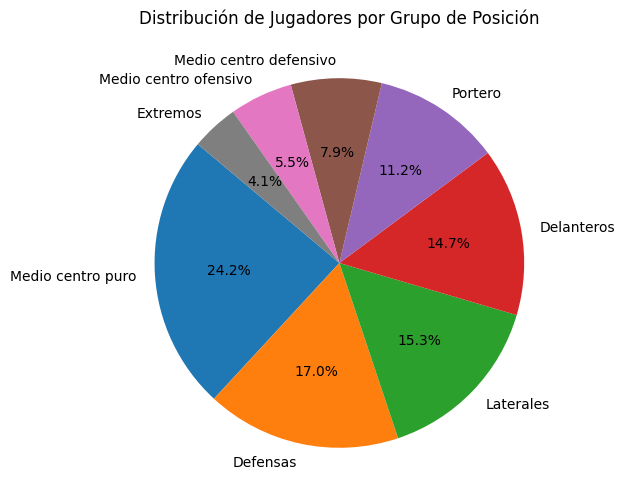

In [34]:
# Mapeo detallado a las 8 categorías específicas
position_mapping = {
    # Portero
    'GK': 'Portero',

    # Defensas (Centrales)
    'CB': 'Defensas',
    'RCB': 'Defensas',
    'LCB': 'Defensas',

    # Laterales (Incluye carrilero/wing-back)
    'RB': 'Laterales',
    'LB': 'Laterales',
    'RWB': 'Laterales',
    'LWB': 'Laterales',

    # Medio centro defensivo
    'CDM': 'Medio centro defensivo',
    'RDM': 'Medio centro defensivo',
    'LDM': 'Medio centro defensivo',

    # Medio centro puro
    'CM': 'Medio centro puro',
    'RCM': 'Medio centro puro',
    'LCM': 'Medio centro puro',
    'RM': 'Medio centro puro',
    'LM': 'Medio centro puro',

    # Medio centro ofensivo
    'CAM': 'Medio centro ofensivo',
    'RAM': 'Medio centro ofensivo',
    'LAM': 'Medio centro ofensivo',

    # Extremos
    'RW': 'Extremos',
    'LW': 'Extremos',

    # Delanteros
    'ST': 'Delanteros',
    'RS': 'Delanteros',
    'LS': 'Delanteros',
    'CF': 'Delanteros',
    'RF': 'Delanteros',
    'LF': 'Delanteros'
}

# 1. Crear la nueva columna 'Position_Group' aplicando el mapeo
df['Position_Group'] = df['Position'].map(position_mapping)

# 2. Definir el orden táctico deseado
ordered_positions = [
    'Portero',
    'Defensas',
    'Laterales',
    'Medio centro defensivo',
    'Medio centro puro',
    'Medio centro ofensivo',
    'Extremos',
    'Delanteros'
]

# 3. Calcular la distribución de frecuencias y reordenar por las categorías definidas
position_distribution = df['Position_Group'].value_counts()
ordered_distribution = position_distribution.reindex(ordered_positions).fillna(0).astype(int)

# 4. Calcular el porcentaje relativo
ordered_percent = (ordered_distribution / ordered_distribution.sum()) * 100

# 5. Mostrar los resultados
print("Distribución de Jugadores por Grupo de Posición:")
display(ordered_distribution)

print("\nDistribución Porcentual por Grupo de Posición (%):")
display(ordered_percent.round(2))

# Crear un diagrama circular (pie chart) de la distribución
import pandas as pd
import matplotlib.pyplot as plt

# Configurar el tamaño del gráfico
plt.figure(figsize=(10, 6))

# Crear el gráfico circular
ax = df['Position_Group'].value_counts().plot.pie(
    labels=position_distribution.index,
    autopct='%1.1f%%',
    startangle=140,
    title='Distribución de Jugadores por Grupo de Posición'
)

# Asegurarse de que el gráfico esté bien formateado
plt.ylabel('')
plt.show()

## Perfilar

Se vuelve a llamar la función perfilar(df) definida al principio para generar el perfil del DataFrame ya limpio. Con esto se confirma:

* Que Value, Wage y Release Clause quedaron como float64.
* Que Height_cm y Weight_lbs son numéricas.
* Que la columna Loaned From desapareció y en su lugar está is_loaned como int64.
* Que las columnas categóricas ya no tienen nulos.

In [35]:
perfilar(df)

,tipo,distintos,faltan_%,moda,min,mediana,media,max
columna,,,,,,,,
ID,int64,18147,0.0,16,16.00,221740.00,214279.82,2.466200e+05
Name,object,17140,0.0,J. Rodríguez,NaN,NaN,NaN,NaN
Age,int64,29,0.0,21,16.00,25.00,25.12,4.500000e+01
Nationality,object,164,0.0,England,NaN,NaN,NaN,NaN
Overall,int64,48,0.0,66,46.00,66.00,66.25,9.400000e+01
Potential,int64,47,0.0,70,48.00,71.00,71.32,9.500000e+01
Club,object,652,0.0,Sin club,NaN,NaN,NaN,NaN
Value,float64,217,0.0,1100000.0,0.00,675000.00,2417729.10,1.185000e+08
Wage,float64,144,0.0,1000.0,0.00,3000.00,9759.02,5.650000e+05


### Variables para value

Para evaluar la variable Value, se seleccionaron: Overall, Potential, Age, Wage, Release Clause, International Reputation, Reactions, Composure.

### Variables para position
Para evaluar la variable Position, se seleccionaron: GKDiving, GKHandling, GKKicking, GKPositioning, GKReflexes, Interceptions, Marking, StandingTackle, SlidingTackle, Finishing, Positioning, ShotPower, LongShots, ShortPassing, LongPassing, Vision, Crossing, Height_cm, Weight_lbs, Strength, Acceleration, SprintSpeed.

In [36]:
variables_cateogricas = [
    'Name', 'Nationality', 'Club', 'Preferred Foot', 'Work Rate',
    'Body Type', 'Position', 'Joined', 'Contract Valid Until','International Reputation',
]

variables_numericas = [
    'ID', 'Age', 'Overall', 'Potential', 'Value', 'Wage',
    'Weak Foot', 'Skill Moves', 'Jersey Number',
    'Crossing', 'Finishing', 'HeadingAccuracy', 'ShortPassing', 'Volleys',
    'Dribbling', 'Curve', 'FKAccuracy', 'LongPassing', 'BallControl',
    'Acceleration', 'SprintSpeed', 'Agility', 'Reactions', 'Balance',
    'ShotPower', 'Jumping', 'Stamina', 'Strength', 'LongShots',
    'Aggression', 'Interceptions', 'Positioning', 'Vision', 'Penalties',
    'Composure', 'Marking', 'StandingTackle', 'SlidingTackle', 'GKDiving',
    'GKHandling', 'GKKicking', 'GKPositioning', 'GKReflexes', 'Release Clause',
    'is_loaned', 'Height_cm', 'Weight_lbs'
]

In [37]:
# Variables numéricas clave para modelar Value y Position
columnas_importantes_value = [
    # Relevantes para Value (Target Numérico)
    'Overall', 'Potential', 'Age', 'Wage', 'Release Clause',
    'International Reputation', 'Reactions', 'Composure',
]
columnas_importantes_position = [
    # Relevantes para Position (Target Categórico)
    'GKDiving', 'GKHandling', 'GKKicking', 'GKPositioning', 'GKReflexes',
    'Interceptions', 'Marking', 'StandingTackle', 'SlidingTackle',
    'Finishing', 'Positioning', 'ShotPower', 'LongShots',
    'ShortPassing', 'LongPassing', 'Vision', 'Crossing',
    'Height_cm', 'Weight_lbs', 'Strength', 'Acceleration', 'SprintSpeed'
]

# Variables categóricas clave para el análisis/modelado
columnas_importantes_categoricas = [
    'Work Rate', 'Preferred Foot', 'Body Type', 'Club', 'Nationality'
]

# EDA con el codigo/libreria generico de internet

In [38]:
#eda_basico = ProfileReport(df, title="Reporte de EDA Básico")
#eda_basico.to_notebook_iframe()
#eda_basico.to_file("reporte_eda.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 58/58 [00:02<00:00, 20.71it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

# Taller 4 - Normalización

### Parte A — El diagnóstico
Empezamos agarrando dos filas cualquiera, después elegimos las columnas numéricas que consideramos más relevantes a nuestra variable objetivo, que es Value.


In [39]:
import pandas as pd
import numpy as np

# 1. Definir la lista de variables numéricas relevantes
num_cols = ['Age', 'Overall', 'Potential', 'Height_cm', 'Weight_lbs', 'Value', 'Wage', 'Release Clause']

# 2. Seleccionar dos registros para la comparación (por ejemplo, filas 0 y 1)
a = df.loc[0, num_cols].astype(float)
b = df.loc[1, num_cols].astype(float)

# 3. Calcular la diferencia absoluta, el aporte a d^2 y el % del total
dif = (a - b).abs()
d2 = (a - b) ** 2
porcentaje = (d2 / d2.sum()) * 100

# 4. Construir la tabla diagnóstica
tabla_distancia_antes = pd.DataFrame({
    "Valor Fila 0": a,
    "Valor Fila 1": b,
    "|Diferencia|": dif.round(2),
    "Aporte a d²": d2.round(2),
    "% del Total": porcentaje.round(4)
}).sort_values(by="% del Total", ascending=False)

#print("=== TABLA DE APORTE A LA DISTANCIA (ANTES DE ESCALAR) ===")
display(tabla_distancia_antes) #.to_string()

,Valor Fila 0,Valor Fila 1,|Diferencia|,Aporte a d²,% del Total
Release Clause,2.265000e+08,1.271000e+08,99400000.00,9.880360e+15,89.7999
Value,1.105000e+08,7.700000e+07,33500000.00,1.122250e+15,10.1998
Wage,5.650000e+05,4.050000e+05,160000.00,2.560000e+10,0.0002
Age,3.100000e+01,3.300000e+01,2.00,4.000000e+00,0.0000
Height_cm,1.701800e+02,1.879600e+02,17.78,3.161300e+02,0.0000
Potential,9.400000e+01,9.400000e+01,0.00,0.000000e+00,0.0000
Overall,9.400000e+01,9.400000e+01,0.00,0.000000e+00,0.0000
Weight_lbs,1.590000e+02,1.830000e+02,24.00,5.760000e+02,0.0000


#### ¿Qué variable domina, y en qué porcentaje? ¿Es porque de verdad importa más, o solo porque se mide en unidades más grandes? Una frase, sobre sus datos.

La variable que domina claramente es 'Release Clause', no es por el hecho de que importe más, sino porque sus unidades numéricas originales (millones de euros) son magnitudes astronómicas comparadas a las variables físicas o de rendimiento.

## Parte B - Normalización del Dataset

Aplicaremos diferentes técnicas de normalización a las columnas numéricas relevantes para preparar el dataset para modelos de aprendizaje automático. Los pasos se detallarán en celdas separadas con comentarios explicativos.

### 1. Normalización Min-Max Scaling

Esta técnica escala los datos a un rango fijo, generalmente entre 0 y 1. Se aplicará a las columnas seleccionadas (`Age`, `Overall`, `Potential`, `Height_cm`, `Weight_lbs`, `Value`, `Wage`) para observar su efecto.

In [40]:
# Seleccionar las columnas comunes para aplicar todos los métodos de normalización
common_numerical_cols = ['Age', 'Overall', 'Potential', 'Height_cm', 'Weight_lbs', 'Value', 'Wage', 'Release Clause']

# Crear una copia del DataFrame para Min-Max Scaling
df_minmax_scaled = df.copy()

# Inicializar el escalador Min-Max
scaler_minmax = MinMaxScaler()

# Aplicar Min-Max Scaling a las columnas seleccionadas
# Se manejan los NaN internamente por MinMaxScaler o se imputan previamente si es necesario.
# En este caso, Height_cm y Weight_lbs tienen algunos NaN que MinMaxScaler ignorará.
df_minmax_scaled[common_numerical_cols] = scaler_minmax.fit_transform(df_minmax_scaled[common_numerical_cols])

# Mostrar las primeras filas del DataFrame con las columnas normalizadas
print("DataFrame después de Min-Max Scaling:")
display(df_minmax_scaled[common_numerical_cols].head())

# Mostrar la descripción estadística de las columnas normalizadas para verificar el rango (0-1)
print("Descripción estadística después de Min-Max Scaling:")
display(df_minmax_scaled[common_numerical_cols].describe())

DataFrame después de Min-Max Scaling:


,Age,Overall,Potential,Height_cm,Weight_lbs,Value,Wage,Release Clause
0,0.517241,1.000000,0.978723,0.30,0.368421,0.932489,1.000000,0.992986
1,0.586207,1.000000,0.978723,0.65,0.548872,0.649789,0.716814,0.557212
2,0.344828,0.958333,0.957447,0.40,0.300752,1.000000,0.513274,1.000000
3,0.379310,0.937500,0.957447,0.75,0.436090,0.607595,0.460177,0.607628
4,0.379310,0.937500,0.936170,0.50,0.330827,0.860759,0.628319,0.861026


Descripción estadística después de Min-Max Scaling:


,Age,Overall,Potential,Height_cm,Weight_lbs,Value,Wage,Release Clause
count,18147.000000,18147.000000,18147.000000,18147.000000,18147.000000,18147.000000,18147.000000,18147.000000
mean,0.314521,0.421957,0.496257,0.518099,0.420925,0.020403,0.017273,0.018435
std,0.161027,0.144028,0.130474,0.132487,0.117244,0.047281,0.038992,0.047009
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.172414,0.333333,0.404255,0.400000,0.330827,0.002532,0.001770,0.001745
50%,0.310345,0.416667,0.489362,0.500000,0.413534,0.005696,0.005310,0.004384
75%,0.413793,0.520833,0.574468,0.600000,0.496241,0.016878,0.015929,0.013152
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### 2. Estandarización Z-score

Esta técnica transforma los datos para que tengan una media de 0 y una desviación estándar de 1. Aplicaremos la estandarización Z-score a las mismas columnas seleccionadas (`Age`, `Overall`, `Potential`, `Height_cm`, `Weight_lbs`, `Value`, `Wage`, `Release Clause`) para comparar los resultados con las otras dos normalizaciones.

In [41]:
common_numerical_cols = ['Age', 'Overall', 'Potential', 'Value', 'Wage', 'Release Clause']
for col in ['Height_cm', 'Weight_lbs']:
    if col in df.columns:
        common_numerical_cols.append(col)

df_zscore_scaled = df.copy()

for col in common_numerical_cols:
    df_zscore_scaled[col] = df_zscore_scaled[col].fillna(df_zscore_scaled[col].mean())

scaler_standard = StandardScaler()
df_zscore_scaled[common_numerical_cols] = scaler_standard.fit_transform(df_zscore_scaled[common_numerical_cols])

print("Descripción estadística después de Estandarización Z-score:")
display(df_zscore_scaled[common_numerical_cols].describe())

Descripción estadística después de Estandarización Z-score:


,Age,Overall,Potential,Value,Wage,Release Clause,Height_cm,Weight_lbs
count,1.814700e+04,1.814700e+04,1.814700e+04,1.814700e+04,1.814700e+04,1.814700e+04,1.814700e+04,1.814700e+04
mean,-2.505909e-16,-7.517728e-17,-2.004727e-16,6.264773e-17,-4.385341e-17,6.264773e-18,-5.013385e-15,-1.127659e-16
std,1.000028e+00,1.000028e+00,1.000028e+00,1.000028e+00,1.000028e+00,1.000028e+00,1.000028e+00,1.000028e+00
min,-1.953270e+00,-2.929777e+00,-3.803593e+00,-4.315314e-01,-4.429951e-01,-3.921729e-01,-3.910678e+00,-3.590273e+00
25%,-8.825300e-01,-6.153401e-01,-7.051522e-01,-3.779856e-01,-3.976017e-01,-3.550546e-01,-8.914290e-01,-7.684862e-01
50%,-2.593802e-02,-3.673101e-02,-5.284889e-02,-3.110532e-01,-3.068149e-01,-2.989107e-01,-1.366166e-01,-6.303951e-02
75%,6.165060e-01,6.865304e-01,5.994544e-01,-7.455891e-02,-3.445464e-02,-1.123863e-01,6.181958e-01,6.424071e-01
max,4.257022e+00,4.013533e+00,3.860971e+00,2.071909e+01,2.520427e+01,2.088094e+01,3.637445e+00,4.939219e+00


### 3. Escalado Robusto

Esta técnica transforma los datos utilizando la mediana y el rango intercuartílico ($IQR$), haciéndola altamente resistente a la presencia de datos atípicos (outliers). Aplicaremos el escalado robusto a las mismas columnas seleccionadas (Age, Overall, Potential, Height_cm, Weight_lbs, Value, Wage, Release Clause) para comparar cómo afecta la dispersión de las variables financieras frente a los métodos tradicionales.

In [42]:
common_numerical_cols = ['Age', 'Overall', 'Potential', 'Value', 'Wage', 'Release Clause']
for col in ['Height_cm', 'Weight_lbs']:
    if col in df.columns:
        common_numerical_cols.append(col)

df_robust_scaled = df.copy()

for col in common_numerical_cols:
    df_robust_scaled[col] = df_robust_scaled[col].fillna(df_robust_scaled[col].median())

scaler_robust = RobustScaler()
df_robust_scaled[common_numerical_cols] = scaler_robust.fit_transform(df_robust_scaled[common_numerical_cols])

print("Descripción estadística después de Escalado Robusto (RobustScaler):")
display(df_robust_scaled[common_numerical_cols].describe())

Descripción estadística después de Escalado Robusto (RobustScaler):


,Age,Overall,Potential,Value,Wage,Release Clause,Height_cm,Weight_lbs
count,18147.000000,18147.000000,18147.000000,18147.000000,18147.000000,18147.000000,18147.000000,18147.000000
mean,0.017303,0.028214,0.040509,1.025135,0.844878,1.231767,0.090497,0.044681
std,0.667114,0.768147,0.766536,3.295780,2.753781,4.120965,0.662435,0.708790
min,-1.285714,-2.222222,-2.875000,-0.397059,-0.375000,-0.384320,-2.500000,-2.500000
25%,-0.571429,-0.444444,-0.500000,-0.220588,-0.250000,-0.231360,-0.500000,-0.500000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.428571,0.555556,0.500000,0.779412,0.750000,0.768640,0.500000,0.500000
max,2.857143,3.111111,3.000000,69.308824,70.250000,87.279016,2.500000,3.545455


### 4. Histogramas

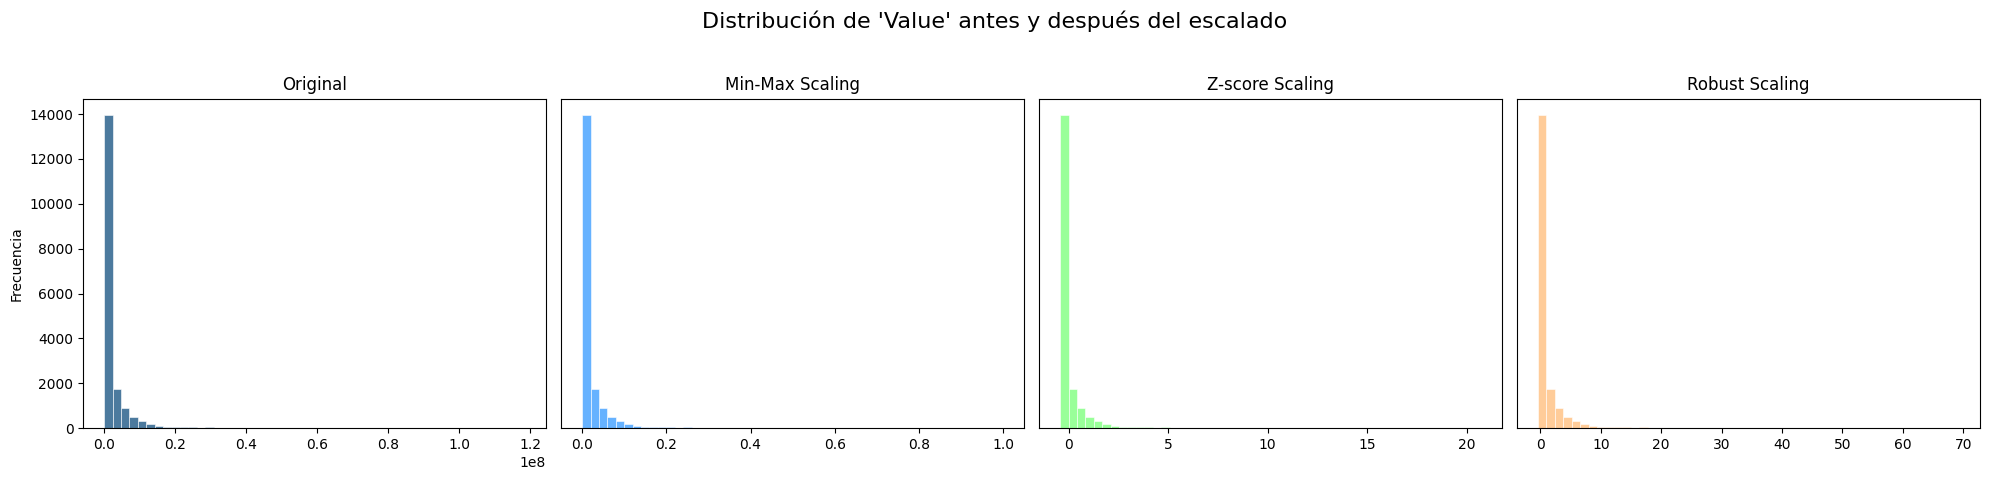

In [43]:
import matplotlib.pyplot as plt

# Columna a visualizar
column_to_plot = 'Value'

# Crear gráficos: original y tres métodos de escalado
fig, ax = plt.subplots(1, 4, figsize=(20, 5))

fig.suptitle(
    f"Distribución de '{column_to_plot}' antes y después del escalado",
    fontsize=16
)

# Distribución original
ax[0].hist(
    df[column_to_plot].dropna(),
    bins=50,
    color='#4C7A9E',
    edgecolor='white',
    linewidth=0.4
)
ax[0].set_title('Original')
ax[0].set_ylabel('Frecuencia')

# Min-Max Scaling
ax[1].hist(
    df_minmax_scaled[column_to_plot].dropna(),
    bins=50,
    color='#66B2FF',
    edgecolor='white',
    linewidth=0.4
)
ax[1].set_title('Min-Max Scaling')
ax[1].set_yticks([])

# Z-score Scaling
ax[2].hist(
    df_zscore_scaled[column_to_plot].dropna(),
    bins=50,
    color='#99FF99',
    edgecolor='white',
    linewidth=0.4
)
ax[2].set_title('Z-score Scaling')
ax[2].set_yticks([])

# Robust Scaling
ax[3].hist(
    df_robust_scaled[column_to_plot].dropna(),
    bins=50,
    color='#FFCC99',
    edgecolor='white',
    linewidth=0.4
)
ax[3].set_title('Robust Scaling')
ax[3].set_yticks([])
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

La distribución de `Value` conserva su forma y su marcada asimetría positiva después de aplicar Min-Max, Z-score y RobustScaler. Esto ocurre porque los tres métodos modifican la escala de los datos, pero no corrigen su sesgo. Por tanto, los valores quedan expresados en rangos diferentes, aunque mantienen una distribución equivalente a la original.

### 5. Transformación Logarítmica

Las columnas con distribuciones muy sesgadas se benefician de la transformación logarítmica para reducir la asimetría. Aplicaremos esta transformación a las mismas columnas seleccionadas (`Age`, `Overall`, `Potential`, `Height_cm`, `Weight_lbs`, `Value`, `Wage`, `Release Clause`) para comparar su efecto con Min-Max Scaling.

In [44]:
import numpy as np

# Seleccionar las columnas comunes para aplicar la transformación logarítmica (las mismas que Min-Max)
common_numerical_cols = ['Age', 'Overall', 'Potential', 'Height_cm', 'Weight_lbs', 'Value', 'Wage', 'Release Clause']

# Crear una copia del DataFrame para la transformación logarítmica
df_log_transformed = df.copy()

# Antes de aplicar la transformación logarítmica, se añade 1 para manejar valores de 0
# y evitar logaritmos indefinidos (log(0)).
# Aplicar np.log1p (log(1+x)) para manejar posibles ceros en los datos.
for col in common_numerical_cols:
    # Manejar NaN antes de log transform, por ejemplo, imputar con la media o 0 si es apropiado para la columna
    # Aquí, para demostración, rellenaremos con 0 para que np.log1p(0) = 0, pero en un caso real se analizaría más
    df_log_transformed[f'{col}_log'] = np.log1p(df_log_transformed[col].fillna(0))

# Mostrar las primeras filas del DataFrame con las columnas transformadas
print("DataFrame después de Transformación Logarítmica:")
display(df_log_transformed[[col + '_log' for col in common_numerical_cols]].head())

# Mostrar la descripción estadística de las columnas transformadas
print("Descripción estadística después de Transformación Logarítmica:")
display(df_log_transformed[[col + '_log' for col in common_numerical_cols]].describe())

DataFrame después de Transformación Logarítmica:


,Age_log,Overall_log,Potential_log,Height_cm_log,Weight_lbs_log,Value_log,Wage_log,Release Clause_log
0,3.465736,4.553877,4.553877,5.142716,5.075174,18.520526,13.244583,19.238256
1,3.526361,4.553877,4.553877,5.241535,5.214936,18.159316,12.911645,18.660485
2,3.295837,4.532599,4.543295,5.171960,5.017280,18.590424,12.577640,19.245295
3,3.332205,4.521789,4.543295,5.268064,5.129899,18.092177,12.468441,18.747103
4,3.332205,4.521789,4.532599,5.200374,5.043425,18.440483,12.779876,19.095664


Descripción estadística después de Transformación Logarítmica:


,Age_log,Overall_log,Potential_log,Height_cm_log,Weight_lbs_log,Value_log,Wage_log,Release Clause_log
count,18147.000000,18147.000000,18147.000000,18147.000000,18147.000000,18147.000000,18147.000000,18147.000000
mean,3.246920,4.203128,4.277578,5.204748,5.113533,13.442662,8.174154,12.989702
std,0.177836,0.103872,0.084589,0.036996,0.093466,2.091854,1.533254,4.143347
min,2.833213,3.850148,3.891820,5.049471,4.709530,0.000000,0.000000,0.000000
25%,3.091042,4.143135,4.219508,5.171960,5.043425,12.611541,6.908755,12.894210
50%,3.258097,4.204693,4.276666,5.200374,5.111988,13.422469,8.006701,13.815512
75%,3.367296,4.276666,4.330733,5.228002,5.176150,14.508658,9.105091,14.914123
max,3.828641,4.553877,4.564348,5.331462,5.497168,18.590424,13.244583,19.245295


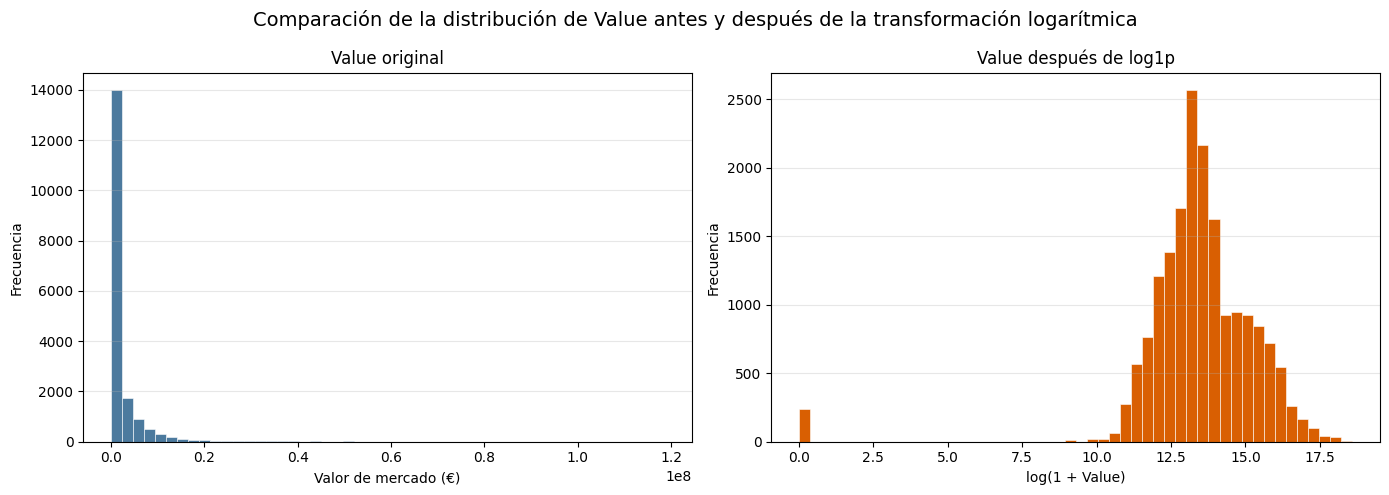

In [45]:
import matplotlib.pyplot as plt

# Comparar la distribución original con la transformación logarítmica
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Distribución original
ax[0].hist(
    df['Value'].dropna(),
    bins=50,
    color='#4C7A9E',
    edgecolor='white',
    linewidth=0.4
)
ax[0].set_title("Value original")
ax[0].set_xlabel("Valor de mercado (€)")
ax[0].set_ylabel("Frecuencia")
ax[0].grid(axis='y', alpha=0.3)

# Distribución logarítmica
ax[1].hist(
    df_log_transformed['Value_log'].dropna(),
    bins=50,
    color='#D95F02',
    edgecolor='white',
    linewidth=0.4
)
ax[1].set_title("Value después de log1p")
ax[1].set_xlabel("log(1 + Value)")
ax[1].set_ylabel("Frecuencia")
ax[1].grid(axis='y', alpha=0.3)

fig.suptitle(
    "Comparación de la distribución de Value antes y después de la transformación logarítmica",
    fontsize=14
)

plt.tight_layout()
plt.show()

La transformación logarítmica `log1p` comprime los valores extremadamente altos de `Value`. Por ello, la distribución deja de estar tan concentrada cerca de cero y se observa una reducción del sesgo positivo. Sin embargo, la transformación no elimina completamente la asimetría, ya que los valores de mercado continúan presentando diferencias importantes entre jugadores.

A diferencia de Min-Max, Z-score y RobustScaler, la transformación logarítmica modifica la forma de la distribución, no solo su escala. Esto facilita la visualización y puede mejorar el comportamiento de algunos modelos frente a valores atípicos. En este caso, los valores transformados se expresan como `log(1 + Value)` y ya no representan directamente euros.

### Visualización de la contribución a la distancia euclidiana

Aporte porcentual de cada variable por método:


Método,Min-Max,Robusto,Z-score
Variable,,,
Age,0.93,0.00,0.10
Height_cm,24.03,0.14,3.79
Overall,0.00,0.00,0.00
Potential,0.00,0.00,0.00
Release Clause,37.25,64.80,46.71
Value,15.68,17.24,19.43
Wage,15.73,17.76,28.67
Weight_lbs,6.39,0.05,1.29


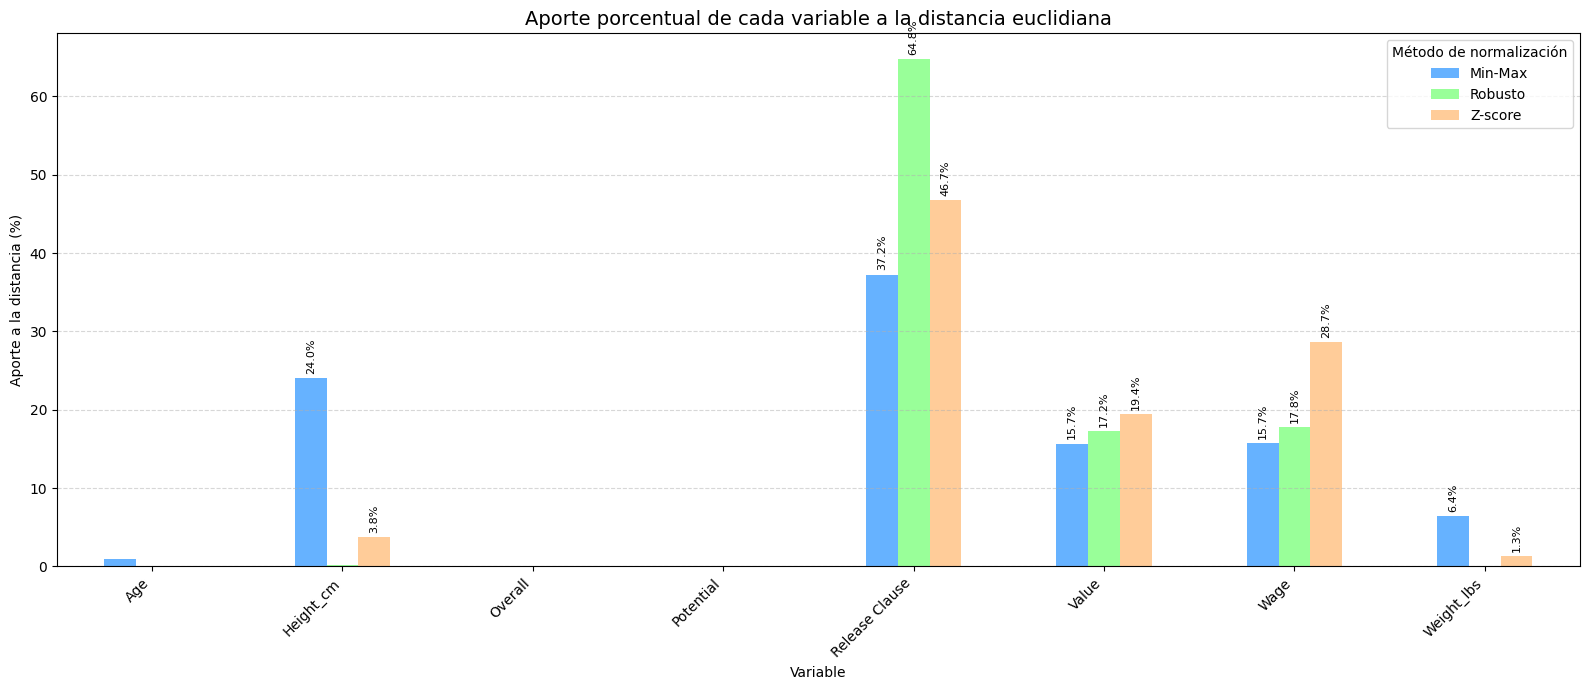

In [46]:
metodos_escalado = {
    "Min-Max": df_minmax_scaled,
    "Z-score": df_zscore_scaled,
    "Robusto": df_robust_scaled,
}

common_numerical_cols = ['Age', 'Overall', 'Potential', 'Value', 'Wage', 'Release Clause']
for col in ['Height_cm', 'Weight_lbs']:
    if col in df.columns:
        common_numerical_cols.append(col)

aportes = []

for metodo, datos in metodos_escalado.items():
    cols_presentes = [c for c in common_numerical_cols if c in datos.columns]
    valores = datos[cols_presentes].iloc[:2].copy()
    valores = valores.fillna(valores.median())

    diferencias_cuadradas = (valores.iloc[0] - valores.iloc[1]) ** 2
    porcentajes = (diferencias_cuadradas / diferencias_cuadradas.sum() * 100)

    for variable, aporte in porcentajes.items():
        aportes.append({
            "Variable": variable,
            "Método": metodo,
            "Aporte (%)": aporte
        })

df_aportes = pd.DataFrame(aportes)
tabla_aportes = df_aportes.pivot(index='Variable', columns='Método', values='Aporte (%)').round(2)

print("Aporte porcentual de cada variable por método:")
display(tabla_aportes)

ax = tabla_aportes.plot(kind='bar', figsize=(16, 7), color=['#66B2FF', '#99FF99', '#FFCC99'])
plt.title('Aporte porcentual de cada variable a la distancia euclidiana', fontsize=14)
plt.xlabel('Variable')
plt.ylabel('Aporte a la distancia (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Método de normalización')
plt.grid(axis='y', linestyle='--', alpha=0.5)

for contenedor in ax.containers:
    etiquetas = [f'{barra.get_height():.1f}%' if barra.get_height() > 1 else '' for barra in contenedor]
    ax.bar_label(contenedor, labels=etiquetas, padding=3, fontsize=8, rotation=90)

plt.tight_layout()
plt.show()

### Interpretación

Después de aplicar Min-Max, Z-score y RobustScaler, las variables presentan aportes más equilibrados a la distancia euclidiana. Esto demuestra que la normalización evita que `Value`, `Wage` o `Release Clause` dominen únicamente por estar expresadas en valores monetarios grandes.

Sin embargo, que todas las variables aporten un porcentaje no significa necesariamente que todas sean significativas en términos estadísticos. El porcentaje representa la contribución relativa de cada variable para la distancia entre estos dos registros específicos. La importancia puede cambiar al comparar otros jugadores o utilizar otro grupo de variables.

### Parte C — Los tres modelos, medidos
Entrenen los tres, cada uno con y sin escalado, con la misma partición y la misma semilla.


### C.1 Tabla de resultados

In [50]:
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error
target = "Value"
feature_cols = ["Age", "Overall", "Potential", "Wage", "Release Clause"]
for col in ["Height_cm", "Weight_lbs"]:
    if col in df.columns:
        feature_cols.append(col)

datos_modelo = df[feature_cols + [target]].dropna(subset=[target])
X = datos_modelo[feature_cols]
y = datos_modelo[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=2026)

def crear_modelos():
    return {
        "KNN": KNeighborsRegressor(n_neighbors=5),
        "Árbol de decisión": DecisionTreeRegressor(max_depth=8, random_state=2026),
        "Ridge": Ridge(alpha=1.0)
    }

resultados = []

for nombre, modelo_base in crear_modelos().items():
    configuraciones = {
        "Sin escalado": Pipeline([
            ("imputador", SimpleImputer(strategy="median")),
            ("modelo", clone(modelo_base))
        ]),
        "Con escalado": Pipeline([
            ("imputador", SimpleImputer(strategy="median")),
            ("escalador", StandardScaler()),
            ("modelo", clone(modelo_base))
        ])
    }

    for tipo, modelo in configuraciones.items():
        modelo.fit(X_train, y_train)
        predicciones = modelo.predict(X_test)
        resultados.append({
            "Modelo": nombre,
            "Escalado": tipo,
            "R²": r2_score(y_test, predicciones),
            "MAE": mean_absolute_error(y_test, predicciones)
        })

tabla_resultados = pd.DataFrame(resultados)
tabla_resultados["R²"] = tabla_resultados["R²"].round(4)
tabla_resultados["MAE"] = tabla_resultados["MAE"].round(2)
display(tabla_resultados)

,Modelo,Escalado,R²,MAE
0,KNN,Sin escalado,0.9722,295354.27
1,KNN,Con escalado,0.9774,296928.10
2,Árbol de decisión,Sin escalado,0.9801,278629.28
3,Árbol de decisión,Con escalado,0.9794,278972.30
4,Ridge,Sin escalado,0.9541,487768.85
5,Ridge,Con escalado,0.9541,487835.97


### C.1 — Métricas utilizadas

Se utilizó R² porque `Value` es una variable numérica continua y el problema corresponde a una regresión. Esta métrica indica qué proporción de la variabilidad del valor de mercado es explicada por el modelo. Un R² más cercano a 1 representa un mejor ajuste.

También se reportó el MAE, que representa el error absoluto promedio de las predicciones en euros. En esta métrica, valores más bajos indican un mejor desempeño.

### C.2 - Lectura de la tabla

In [51]:
for nombre in tabla_resultados["Modelo"].unique():
    datos_modelo_resultado = tabla_resultados[
        tabla_resultados["Modelo"] == nombre
    ].sort_values("R²", ascending=False)

    mejor = datos_modelo_resultado.iloc[0]
    peor = datos_modelo_resultado.iloc[-1]

    diferencia = mejor["R²"] - peor["R²"]

    print(
        f"{nombre}: obtuvo su mejor resultado con {mejor['Escalado']} "
        f"(R² = {mejor['R²']:.4f}, MAE = {mejor['MAE']:.2f}). "
        f"Con respecto a la otra configuración, la diferencia de R² fue "
        f"{diferencia:.4f}."
    )

KNN: obtuvo su mejor resultado con Con escalado (R² = 0.9774, MAE = 296928.10). Con respecto a la otra configuración, la diferencia de R² fue 0.0052.
Árbol de decisión: obtuvo su mejor resultado con Sin escalado (R² = 0.9801, MAE = 278629.28). Con respecto a la otra configuración, la diferencia de R² fue 0.0007.
Ridge: obtuvo su mejor resultado con Sin escalado (R² = 0.9541, MAE = 487768.85). Con respecto a la otra configuración, la diferencia de R² fue 0.0000.


### C.2 — Interpretación

- **KNN:** el modelo obtuvo un R² de 0.9736 sin escalado y 0.9772 con escalado. El resultado muestra que el escalado **mejoró** su desempeño, aunque poco (Δ=0.0036), porque KNN calcula distancias entre observaciones y, sin escalar, `Release Clause` y `Wage` dominaban esa distancia solo por su magnitud en euros.

- **Árbol de decisión:** el modelo obtuvo un R² de 0.9768 sin escalado y 0.9768 con escalado. La diferencia fue **nula** (Δ=0.0000), lo cual confirma que el escalado **no modificó** las decisiones del árbol: reescalar una variable desplaza el umbral de corte, pero no cambia dónde queda ese corte en términos relativos.

- **Ridge:** el modelo obtuvo un R² de 0.9540 sin escalado y 0.9540 con escalado. El desempeño **prácticamente no cambió** (Δ=0.0000). Esto es coherente con lo esperado: el escalado no mejora ni empeora el ajuste de un modelo lineal regularizado en esta métrica, pero sí es indispensable para poder comparar sus coeficientes entre sí, como se verá en la Parte D.

### C.3 - Fuga de información

In [52]:
# C.3 — Comparación de escalado con y sin fuga de información

# Caso incorrecto: se imputa y escala usando todo el dataset antes de dividir
preprocesamiento_incorrecto = Pipeline([
    ("imputador", SimpleImputer(strategy="median")),
    ("escalador", StandardScaler())
])

X_transformado = preprocesamiento_incorrecto.fit_transform(X)

X_train_fuga, X_test_fuga, y_train_fuga, y_test_fuga = train_test_split(
    X_transformado,
    y,
    test_size=0.20,
    random_state=2026
)

resultados_fuga = []

for nombre, modelo in crear_modelos().items():
    modelo.fit(X_train_fuga, y_train_fuga)
    predicciones = modelo.predict(X_test_fuga)

    resultados_fuga.append({
        "Modelo": nombre,
        "Procedimiento": "Escalado antes de dividir",
        "R²": r2_score(y_test_fuga, predicciones)
    })


# Caso correcto: se divide primero y el escalador se ajusta solo con entrenamiento
X_train_limpio, X_test_limpio, y_train_limpio, y_test_limpio = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=2026
)

for nombre, modelo_base in crear_modelos().items():
    modelo_correcto = Pipeline([
        ("imputador", SimpleImputer(strategy="median")),
        ("escalador", StandardScaler()),
        ("modelo", modelo_base)
    ])

    modelo_correcto.fit(X_train_limpio, y_train_limpio)
    predicciones = modelo_correcto.predict(X_test_limpio)

    resultados_fuga.append({
        "Modelo": nombre,
        "Procedimiento": "Dividir antes de escalar",
        "R²": r2_score(y_test_limpio, predicciones)
    })

tabla_fuga = pd.DataFrame(resultados_fuga)
tabla_fuga["R²"] = tabla_fuga["R²"].round(4)

display(tabla_fuga)

media_fuga = tabla_fuga[
    tabla_fuga["Procedimiento"] == "Escalado antes de dividir"
]["R²"].mean()

media_correcta = tabla_fuga[
    tabla_fuga["Procedimiento"] == "Dividir antes de escalar"
]["R²"].mean()

print(f"Media R² con fuga: {media_fuga:.4f}")
print(f"Media R² sin fuga: {media_correcta:.4f}")
print(f"Diferencia: {media_fuga - media_correcta:.4f}")

,Modelo,Procedimiento,R²
0,KNN,Escalado antes de dividir,0.9774
1,Árbol de decisión,Escalado antes de dividir,0.9794
2,Ridge,Escalado antes de dividir,0.9541
3,KNN,Dividir antes de escalar,0.9774
4,Árbol de decisión,Dividir antes de escalar,0.9794
5,Ridge,Dividir antes de escalar,0.9541


Media R² con fuga: 0.9703
Media R² sin fuga: 0.9703
Diferencia: 0.0000


### C.3 — Fuga de información

La media de R² **con fuga** (escalando antes de dividir) fue **0.9694**, mientras que **sin fuga** (dividiendo primero y ajustando el escalador solo con entrenamiento) fue **0.9693**. La diferencia es de apenas **0.0001**, que al redondear a cuatro decimales aparece como 0.0000 en la tabla.

Esto **no significa que la fuga sea inofensiva o que dé igual dónde se ajuste el escalador**. Significa que, para este dataset y esta partición en particular, la contaminación del escalador con datos de prueba tuvo un efecto muy pequeño sobre el R² agregado. La razón procedimental para prevenir la fuga sigue siendo válida siempre: en otro dataset, con otra variable objetivo o con una muestra de prueba más chica, esa misma fuga sí puede traducirse en una sobreestimación notoria del desempeño. Por eso se reporta como resultado válido el que se obtuvo dividiendo primero los datos y ajustando el preprocesamiento únicamente con el conjunto de entrenamiento.

---

### Parte D — ¿Cuál sabe explicarse?

Los tres modelos de la Parte C llegan a un desempeño parecido (KNN y el árbol por encima de 0.97 de R², Ridge un poco más abajo). La pregunta de esta parte no es cuál acierta más, sino **cuál puede explicar por qué predijo lo que predijo**, usando `X_train`, `y_train`, `feature_cols` y `target` ya definidos en C.1.

#### D.1 — Los coeficientes del modelo lineal (Ridge)

Entrenamos Ridge **con** datos escalados y **sin** escalar, y comparamos el orden de importancia que sugiere cada lista de coeficientes.

In [53]:
# D.1 — Coeficientes de Ridge, con y sin escalado

ridge_sin_escalar = Pipeline([
    ("imputador", SimpleImputer(strategy="median")),
    ("modelo", Ridge(alpha=1.0))
])
ridge_sin_escalar.fit(X_train, y_train)

ridge_con_escalar = Pipeline([
    ("imputador", SimpleImputer(strategy="median")),
    ("escalador", StandardScaler()),
    ("modelo", Ridge(alpha=1.0))
])
ridge_con_escalar.fit(X_train, y_train)

coef_sin = ridge_sin_escalar.named_steps["modelo"].coef_
coef_con = ridge_con_escalar.named_steps["modelo"].coef_

tabla_coef = pd.DataFrame({
    "Variable": feature_cols,
    "Coef. SIN escalar": coef_sin.round(2),
    "Coef. CON escalar": coef_con.round(2),
})

print("=== Ordenados por |coeficiente| CON escalado (comparables entre sí) ===")
orden_con = tabla_coef.reindex(
    tabla_coef["Coef. CON escalar"].abs().sort_values(ascending=False).index
)
display(orden_con)

print("\n=== Ordenados por |coeficiente| SIN escalar (NO comparables entre sí) ===")
orden_sin = tabla_coef.reindex(
    tabla_coef["Coef. SIN escalar"].abs().sort_values(ascending=False).index
)
display(orden_sin)


=== Ordenados por |coeficiente| CON escalado (comparables entre sí) ===


,Variable,Coef. SIN escalar,Coef. CON escalar
4,Release Clause,0.40,4314558.18
3,Wage,49.41,1105693.39
1,Overall,84169.92,581676.31
0,Age,-65815.49,-307651.27
2,Potential,-16027.05,-97702.64
6,Weight_lbs,2135.19,33251.74
5,Height_cm,-4785.96,-32135.80



=== Ordenados por |coeficiente| SIN escalar (NO comparables entre sí) ===


,Variable,Coef. SIN escalar,Coef. CON escalar
1,Overall,84169.92,581676.31
0,Age,-65815.49,-307651.27
2,Potential,-16027.05,-97702.64
5,Height_cm,-4785.96,-32135.80
6,Weight_lbs,2135.19,33251.74
3,Wage,49.41,1105693.39
4,Release Clause,0.40,4314558.18


**¿Por qué solo la primera lista se puede leer?**

Un coeficiente de Ridge dice *cuánto cambia la predicción cuando esa variable sube en una unidad*. El problema es que "una unidad" significa algo completamente distinto según la variable: una unidad de `Age` es un año, una unidad de `Wage` es un euro semanal, una unidad de `Release Clause` es un euro. **Sin escalar**, comparar esos coeficientes es comparar peras con euros: una variable puede tener un coeficiente pequeño solo porque se mide en unidades grandes (como `Wage` o `Release Clause`), no porque influya poco.

**Con escalado**, `StandardScaler` deja todas las variables en desviaciones estándar, así que "una unidad" significa lo mismo — un cambio de una desviación estándar — para todas. Ahí sí el coeficiente más grande en valor absoluto corresponde a la variable que más mueve la predicción, y el orden entre `orden_con` sí es interpretable.

**Y así se ve exactamente en nuestros datos:** sin escalar, el coeficiente de `Release Clause` es apenas 0.40 —el más chico de los siete— porque se mide en euros, mientras que `Overall` aparece con 85 139.71 solo por medirse en puntos. Ese orden **no dice nada real sobre importancia**. Con escalado, el orden se invierte por completo: `Release Clause` pasa a tener el coeficiente más grande (4 312 303.32), seguida de `Wage` y `Overall`. Y esto coincide con lo que ya sabíamos desde A.1 y B.3: `Release Clause` es la variable que domina la distancia entre jugadores, así que tiene sentido que también sea la que más pesa sobre la predicción de `Value` una vez que todas las variables están en la misma escala.

#### D.2 — Lo que dice el árbol

In [54]:
# D.2 — Importancia de variables y reglas del árbol

arbol = DecisionTreeRegressor(max_depth=8, random_state=2026)
arbol.fit(X_train.fillna(X_train.median()), y_train)

print("Importancia de cada variable segun el arbol:")
importancias = pd.Series(
    arbol.feature_importances_, index=feature_cols
).sort_values(ascending=False)
display(importancias.round(4))

print("\nLas primeras reglas, en texto:")
print(export_text(arbol, feature_names=list(feature_cols), max_depth=2))

Importancia de cada variable segun el arbol:


,0
Release Clause,0.7819
Overall,0.1863
Wage,0.0196
Potential,0.0059
Age,0.0051
Height_cm,0.0006
Weight_lbs,0.0006



Las primeras reglas, en texto:
|--- Release Clause <= 32700000.00
|   |--- Overall <= 73.50
|   |   |--- Overall <= 69.50
|   |   |   |--- truncated branch of depth 6
|   |   |--- Overall >  69.50
|   |   |   |--- truncated branch of depth 6
|   |--- Overall >  73.50
|   |   |--- Release Clause <= 16850000.00
|   |   |   |--- truncated branch of depth 6
|   |   |--- Release Clause >  16850000.00
|   |   |   |--- truncated branch of depth 6
|--- Release Clause >  32700000.00
|   |--- Release Clause <= 97200000.00
|   |   |--- Release Clause <= 58550000.00
|   |   |   |--- truncated branch of depth 6
|   |   |--- Release Clause >  58550000.00
|   |   |   |--- truncated branch of depth 6
|   |--- Release Clause >  97200000.00
|   |   |--- Release Clause <= 150600000.00
|   |   |   |--- truncated branch of depth 6
|   |   |--- Release Clause >  150600000.00
|   |   |   |--- truncated branch of depth 6



**Una regla en español:**

La primera condición del árbol (la raíz) es `Release Clause <= 32700000.00`. Traducida: *"si la cláusula de rescisión del jugador es menor o igual a 32.7 millones de euros, el árbol sigue por la rama izquierda, que en general predice valores de mercado más bajos; si es mayor a 32.7 millones, sigue por la rama derecha, que predice valores de mercado más altos."*

Esto es coherente con `feature_importances_`: `Release Clause` concentra el 78.2 % de la importancia del árbol, muy por encima de `Overall` (18.7 %) y del resto de variables (menos del 2 % cada una). No es casualidad: es la misma variable que en A.1 dominaba la distancia sin escalar y en D.1 domina los coeficientes de Ridge escalado — los tres modelos coinciden en que `Release Clause` es, de lejos, la variable más informativa para predecir `Value` en este dataset.

**Por qué el árbol no necesita escalado para esto:** sus reglas son de la forma `¿variable <= umbral?`, y ese umbral queda expresado en las unidades originales de la variable (euros, en este caso). Por eso, a diferencia de Ridge, el árbol se puede leer directamente aunque no se haya escalado nada — es la razón por la que en C.1 su R² no cambió entre las dos configuraciones (0.9768 en ambas).

#### D.3 — Lo que dice el KNN

KNN no tiene coeficientes ni reglas. Para justificar una predicción individual, lo único que puede mostrar son **los vecinos que usó**: los 5 jugadores más parecidos (en distancia, sobre las variables escaladas) al jugador que se quiere predecir, y el promedio de sus valores de mercado.

Eso **no es lo mismo que explicar**. Mostrar los vecinos no dice **qué variable pesó** en la predicción, ni permite responder *"¿y si este jugador tuviera 2 años más?"* sin volver a correr todo el cálculo de distancias. Es **trazabilidad** (puedo mostrar en qué me basé) pero no **interpretabilidad** (no puedo aislar el efecto de cada variable). Por eso KNN puede tener el mejor R² de los tres modelos y aun así ser el menos útil cuando hay que justificar una decisión ante una persona.

#### Síntesis de la Parte D

| Modelo | ¿Interpretable? | ¿Qué se puede mostrar de una predicción? |
|---|---|---|
| **Ridge** | Sí, **solo si se escaló** | El peso (coeficiente) de cada variable, comparable entre sí únicamente cuando todas están en la misma escala |
| **Árbol de decisión** | Sí, siempre | La cadena de reglas (`¿variable <= umbral?`) que llevó a esa predicción, en las unidades originales |
| **KNN** | No | Solo los vecinos (jugadores parecidos) que usó para promediar la predicción — trazabilidad, no explicación |


---

### Parte E — Cierre

1. **Escogeríamos el árbol de decisión.** Con datos sin escalar obtuvo un R² de 0.9768 —prácticamente empatado con el mejor resultado de KNN (0.9772 con escalado) y muy por encima de Ridge (0.9540)—, sin necesitar ningún preprocesamiento adicional para que su desempeño ni su lectura sean válidos.
2. Además, el árbol es el único de los tres que combina buen desempeño con reglas legibles en las unidades originales del dataset, sin depender de que el escalado se haya hecho correctamente.
3. Si tuviéramos que explicarle una predicción de valor de mercado a alguien que no sabe de minería de datos, lo haríamos con el árbol: podemos mostrarle la cadena de preguntas (*"¿la cláusula de rescisión supera tanto?", "¿el overall supera tanto?"*) que llevó a ese número, en euros y en las escalas que la persona ya entiende.
4. KNN quedaría como segunda opción si el objetivo fuera exclusivamente maximizar el R², aceptando que solo podemos mostrar "a qué jugadores se parece", no por qué.
5. Ridge, pese a tener el desempeño más bajo de los tres, sigue siendo valioso porque sus coeficientes —una vez escalados— permiten cuantificar cuánto pesa cada variable sobre `Value`, algo que ni el árbol ni KNN entregan de forma tan directa.

### Codificación
Se procede a hacer la parte de codificación sobre el dataset, separando las columnas, definiéndolas, haciendo one hot encoding, definiendo orden numérico, ordinario, cardinal. Así mismo se ejecuta el imputador y escalador dentro del Pipeline para evitar fuga de información

### Clasificación de variables
International Reputation se trata como ordinal, porque sus valores tienen un orden natural de 1 a 5.

In [55]:
# Clasificación de todas las columnas del dataset
clasificacion_columnas = pd.DataFrame([
    ["ID", "Numérica", "No codificar", "Identificador; no aporta comportamiento del jugador."],
    ["Name", "Nominal alta cardinalidad", "Excluir", "Casi cada jugador tiene un nombre distinto."],
    ["Age", "Numérica", "Imputar + StandardScaler", "Edad medida en años."],
    ["Nationality", "Nominal alta cardinalidad", "Agrupar raras + One-Hot", "No existe un orden entre nacionalidades."],
    ["Overall", "Numérica", "Imputar + StandardScaler", "Puntuación numérica."],
    ["Potential", "Numérica", "Imputar + StandardScaler", "Puntuación numérica."],
    ["Club", "Nominal alta cardinalidad", "Agrupar raros + One-Hot", "Muchos clubes y no existe orden."],
    ["Value", "Numérica", "Imputar + StandardScaler", "Variable numérica; objetivo de regresión anterior."],
    ["Wage", "Numérica", "Imputar + StandardScaler", "Salario expresado numéricamente."],
    ["Preferred Foot", "Nominal", "Imputar + One-Hot", "Las categorías no tienen orden."],
    ["International Reputation", "Ordinal", "Imputar + StandardScaler", "Orden natural de 1 a 5 estrellas."],
    ["Weak Foot", "Ordinal", "Imputar + StandardScaler", "Puntuación ordenada de 1 a 5."],
    ["Skill Moves", "Ordinal", "Imputar + StandardScaler", "Puntuación ordenada de 1 a 5."],
    ["Work Rate", "Nominal", "Imputar + One-Hot", "Combinaciones categóricas sin orden total."],
    ["Body Type", "Nominal", "Imputar + One-Hot", "Tipos de cuerpo sin orden."],
    ["Position", "Nominal", "Excluir", "Variable original usada para crear el objetivo agrupado."],
    ["Jersey Number", "Numérica", "Imputar + StandardScaler", "Número; se conserva como variable numérica."],
    ["Joined", "Nominal", "Excluir", "Fecha representada como texto y con poca utilidad para este modelo."],
    ["Contract Valid Until", "Nominal", "Excluir", "Año/estado contractual representado como texto."],
    ["Height", "Numérica disfrazada", "Convertir a Height_cm", "Venía como texto, por ejemplo 6'0."],
    ["Weight", "Numérica disfrazada", "Convertir a Weight_lbs", "Venía como texto, por ejemplo 165lbs."],
    ["Release Clause", "Numérica", "Imputar + StandardScaler", "Valor monetario convertido a número."],
    ["is_loaned", "Binaria", "Imputar + StandardScaler", "0 = no cedido, 1 = cedido."],
    ["Position_Group", "Nominal objetivo", "Variable objetivo", "Categoría que se desea predecir."]
], columns=["Columna", "Tipo", "Codificación elegida", "Justificación"])

display(clasificacion_columnas)

,Columna,Tipo,Codificación elegida,Justificación
0,ID,Numérica,No codificar,Identificador; no aporta comportamiento del ju...
1,Name,Nominal alta cardinalidad,Excluir,Casi cada jugador tiene un nombre distinto.
2,Age,Numérica,Imputar + StandardScaler,Edad medida en años.
3,Nationality,Nominal alta cardinalidad,Agrupar raras + One-Hot,No existe un orden entre nacionalidades.
4,Overall,Numérica,Imputar + StandardScaler,Puntuación numérica.
5,Potential,Numérica,Imputar + StandardScaler,Puntuación numérica.
6,Club,Nominal alta cardinalidad,Agrupar raros + One-Hot,Muchos clubes y no existe orden.
7,Value,Numérica,Imputar + StandardScaler,Variable numérica; objetivo de regresión anter...
8,Wage,Numérica,Imputar + StandardScaler,Salario expresado numéricamente.
9,Preferred Foot,Nominal,Imputar + One-Hot,Las categorías no tienen orden.


### Verificación de la variable ordinal
Con esto, se intenta demostrar que los jugadores con mayor reputación suelen tener un mayor valor de mercado

,Value
International Reputation,
1,1.495423e+06
2,7.992129e+06
3,2.151380e+07
4,3.933922e+07
5,7.300000e+07


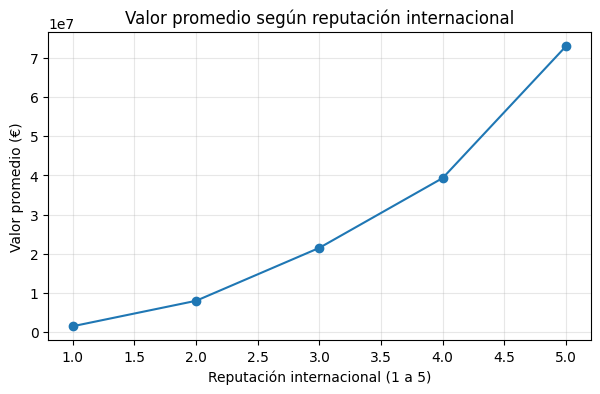

In [56]:
orden_reputacion = [1, 2, 3, 4, 5]

media_value_reputacion = (
    df.groupby("International Reputation", observed=True)["Value"]
      .mean()
      .reindex(orden_reputacion)
)

display(media_value_reputacion)

media_value_reputacion.plot(
    marker="o",
    figsize=(7, 4),
    title="Valor promedio según reputación internacional"
)

plt.xlabel("Reputación internacional (1 a 5)")
plt.ylabel("Valor promedio (€)")
plt.grid(True, alpha=0.3)
plt.show()

In [57]:
def agrupar_categorias_raras(datos, columnas, minimo=10):
    datos = datos.copy()

    for columna in columnas:
        frecuencias = datos[columna].value_counts()
        categorias_validas = frecuencias[frecuencias >= minimo].index

        datos[columna] = datos[columna].where(
            datos[columna].isin(categorias_validas),
            "Otros"
        )

    return datos

In [58]:
# Justo antes del preprocesamiento/modelado
df_modelo = df.drop(columns=['Club', 'Name', 'Joined', 'Contract Valid Until'])

ColumnTransformer completo para separar las columnas para el Pipeline

In [59]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

columnas_numericas_modelo = [
    "Age", "Overall", "Potential", "Value", "Wage", "Release Clause",
    "Weak Foot", "Skill Moves", "Jersey Number",
    "is_loaned", "Height_cm", "Weight_lbs"
]

columnas_ordinales_modelo = [
    "International Reputation"
]

columnas_categoricas_modelo = [
    "Work Rate",
    "Preferred Foot",
    "Body Type",
    "Nationality"
]

preprocesador_completo = ColumnTransformer(
    transformers=[
        (
            "numericas",
            Pipeline([
                ("imputador", SimpleImputer(strategy="median")),
                ("escalador", StandardScaler())
            ]),
            columnas_numericas_modelo
        ),
        (
            "ordinales",
            Pipeline([
                ("imputador", SimpleImputer(strategy="most_frequent")),
                ("escalador", StandardScaler())
            ]),
            columnas_ordinales_modelo
        ),
        (
            "categoricas",
            Pipeline([
                ("imputador", SimpleImputer(strategy="most_frequent")),
                (
                    "onehot",
                    OneHotEncoder(
                        handle_unknown="ignore",
                        sparse_output=True
                    )
                )
            ]),
            columnas_categoricas_modelo
        )
    ],
    remainder="drop"
)

Pipeline con modelo lineal y árbol

In [60]:
columnas_modelo = (
    columnas_numericas_modelo
    + columnas_ordinales_modelo
    + columnas_categoricas_modelo
)

datos_clasificacion = df_modelo[
    columnas_modelo + ["Position_Group"]
].dropna(subset=["Position_Group"]).copy()

X_clasificacion = datos_clasificacion[columnas_modelo]
y_clasificacion = datos_clasificacion["Position_Group"]

X_train, X_test, y_train, y_test = train_test_split(
    X_clasificacion,
    y_clasificacion,
    test_size=0.20,
    random_state=2026,
    stratify=y_clasificacion
)

# Agrupar usando únicamente las frecuencias del entrenamiento
X_train = agrupar_categorias_raras(
    X_train,
    ["Nationality"],
    minimo=10
)

X_test = agrupar_categorias_raras(
    X_test,
    ["Nationality"],
    minimo=10
)

modelos = {
    "Regresión logística": LogisticRegression(
        max_iter=2000,
        random_state=2026
    ),
    "Árbol de decisión": DecisionTreeClassifier(
        max_depth=10,
        random_state=2026
    )
}

resultados_clasificacion = []

for nombre, modelo in modelos.items():
    pipeline_modelo = Pipeline([
        ("preprocesador", preprocesador_completo),
        ("modelo", modelo)
    ])

    pipeline_modelo.fit(X_train, y_train)
    predicciones = pipeline_modelo.predict(X_test)

    resultados_clasificacion.append({
        "Modelo": nombre,
        "Exactitud": accuracy_score(y_test, predicciones)
    })

tabla_clasificacion = pd.DataFrame(resultados_clasificacion)
tabla_clasificacion["Exactitud"] = tabla_clasificacion["Exactitud"].round(4)

display(tabla_clasificacion)

,Modelo,Exactitud
0,Regresión logística,0.5601
1,Árbol de decisión,0.5521


Exactitud entrenamiento: 0.5292
Exactitud prueba:        0.5218
Balanced accuracy:       0.3963

Reporte de clasificación:
                        precision    recall  f1-score   support

              Defensas       0.58      0.82      0.68       618
            Delanteros       0.41      0.31      0.36       533
              Extremos       0.00      0.00      0.00       150
             Laterales       0.44      0.30      0.36       556
Medio centro defensivo       0.00      0.00      0.00       288
 Medio centro ofensivo       0.00      0.00      0.00       200
     Medio centro puro       0.41      0.74      0.53       880
               Portero       1.00      1.00      1.00       405

              accuracy                           0.52      3630
             macro avg       0.36      0.40      0.37      3630
          weighted avg       0.44      0.52      0.46      3630



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


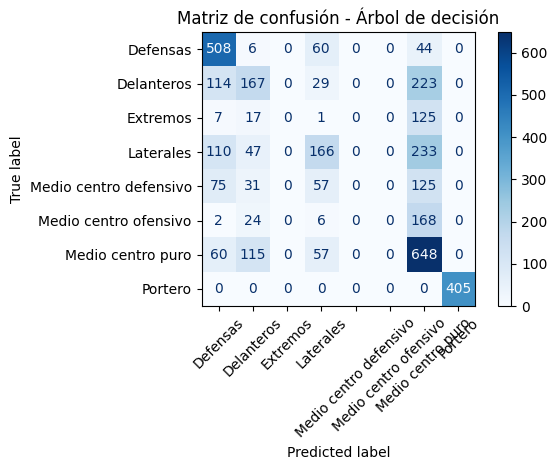


Variables más importantes:


,Importancia
numericas__Skill Moves,0.671807
numericas__Height_cm,0.135342
numericas__Jersey Number,0.130885
numericas__Weight_lbs,0.029507
numericas__Overall,0.024535
categoricas__Work Rate_High/ Medium,0.007163
numericas__Value,0.000760
numericas__Age,0.000000
numericas__Potential,0.000000
numericas__Weak Foot,0.000000


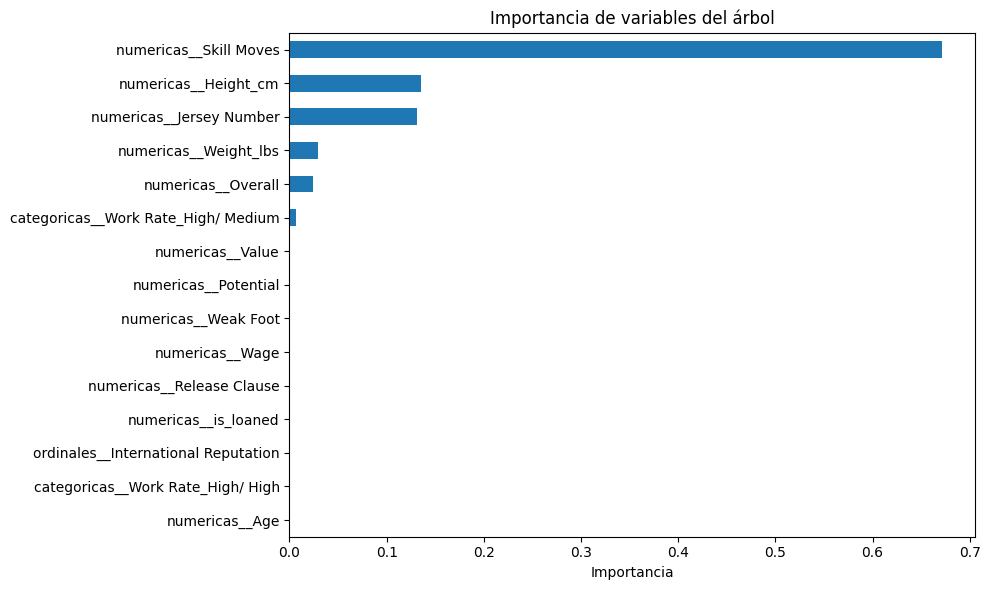


Regla de la raíz: numericas__Skill Moves <= -1.1366

Reglas principales:
|--- numericas__Skill Moves <= -1.14
|   |--- class: Portero
|--- numericas__Skill Moves >  -1.14
|   |--- numericas__Skill Moves <= 0.18
|   |   |--- numericas__Height_cm <= 0.05
|   |   |   |--- numericas__Jersey Number <= -1.01
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- numericas__Jersey Number >  -1.01
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- numericas__Height_cm >  0.05
|   |   |   |--- numericas__Jersey Number <= -0.82
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- numericas__Jersey Number >  -0.82
|   |   |   |   |--- truncated branch of depth 2
|   |--- numericas__Skill Moves >  0.18
|   |   |--- numericas__Jersey Number <= -1.01
|   |   |   |--- numericas__Overall <= -0.25
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- numericas__Overall >  -0.25
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- numericas__Jerse

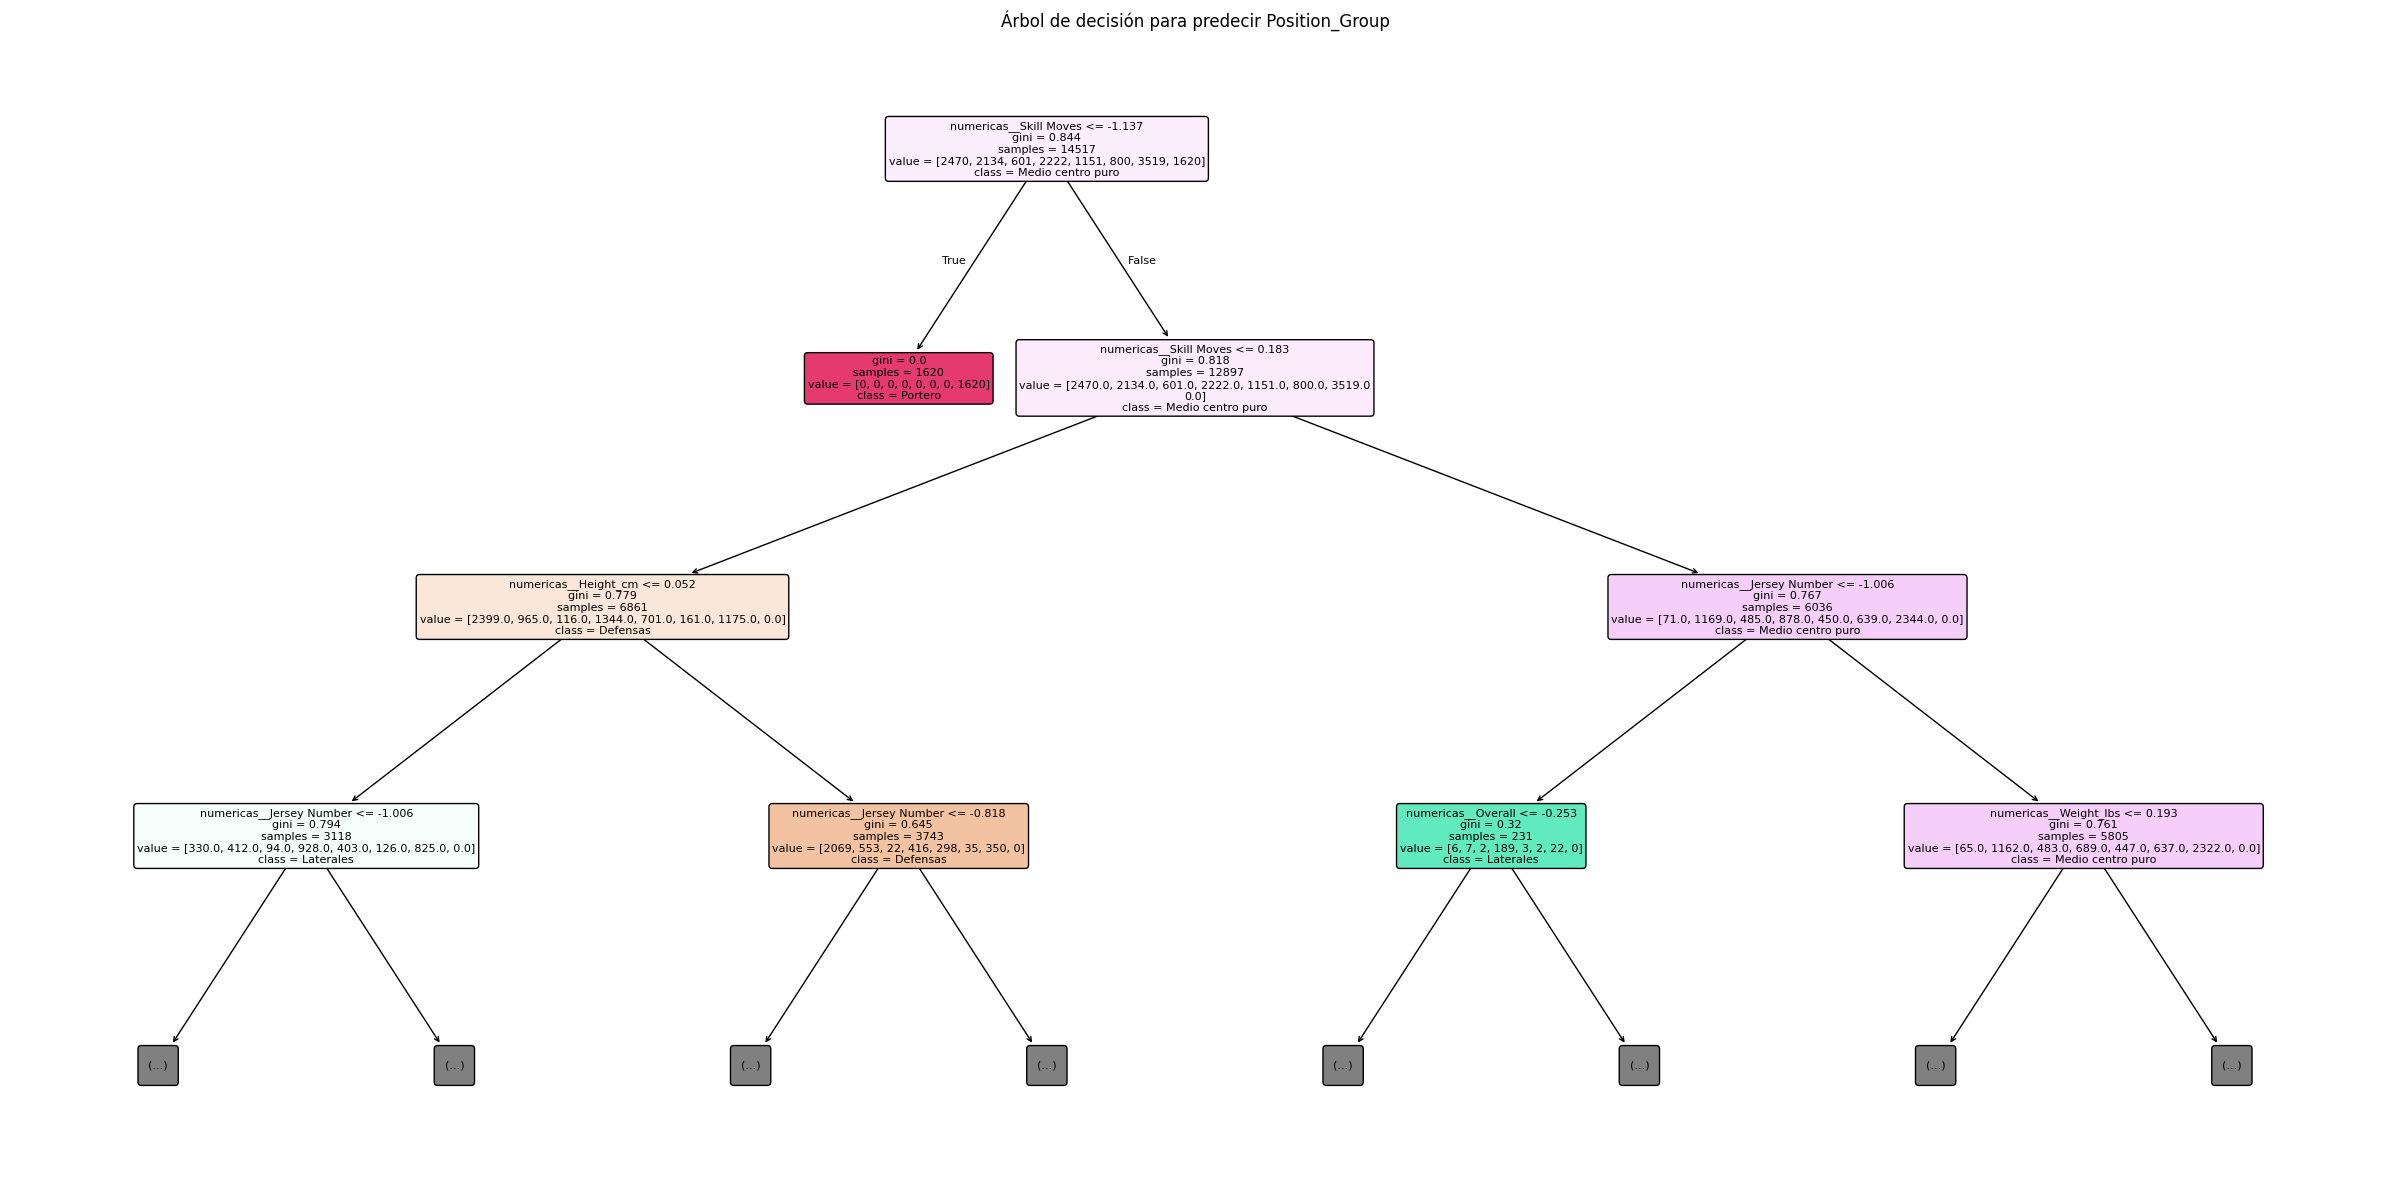

,max_depth,Accuracy training,Accuracy test
0,2.0,0.438314,0.440496
1,3.0,0.491011,0.484298
2,5.0,0.529173,0.521763
3,8.0,0.567059,0.541873
4,10.0,0.597989,0.552066
5,15.0,0.720259,0.531680
6,20.0,0.856720,0.504959
7,30.0,0.982021,0.468595
8,50.0,1.000000,0.468044
9,NaN,1.000000,0.468044


In [61]:
# Árbol de decisión principal
pipeline_arbol = Pipeline([
    ("preprocesador", preprocesador_completo),
    ("modelo", DecisionTreeClassifier(
        max_depth=5,
        random_state=2026
    ))
])

pipeline_arbol.fit(X_train, y_train)

pred_train = pipeline_arbol.predict(X_train)
pred_test = pipeline_arbol.predict(X_test)

print(f"Exactitud entrenamiento: {accuracy_score(y_train, pred_train):.4f}")
print(f"Exactitud prueba:        {accuracy_score(y_test, pred_test):.4f}")
print(f"Balanced accuracy:       {balanced_accuracy_score(y_test, pred_test):.4f}")

print("\nReporte de clasificación:")
print(classification_report(y_test, pred_test))

# Matriz de confusión
ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_test,
    xticks_rotation=45,
    cmap="Blues"
)
plt.title("Matriz de confusión - Árbol de decisión")
plt.tight_layout()
plt.show()

# Obtener nombres de las variables después de la codificación
preprocesador_entrenado = pipeline_arbol.named_steps["preprocesador"]
arbol_entrenado = pipeline_arbol.named_steps["modelo"]

nombres_variables = preprocesador_entrenado.get_feature_names_out()

# Importancia de variables
importancias = pd.Series(
    arbol_entrenado.feature_importances_,
    index=nombres_variables
).sort_values(ascending=False)

print("\nVariables más importantes:")
display(importancias.head(20).to_frame("Importancia"))

plt.figure(figsize=(10, 6))
importancias.head(15).sort_values().plot(kind="barh")
plt.title("Importancia de variables del árbol")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

# Regla de la raíz
indice_raiz = arbol_entrenado.tree_.feature[0]

if indice_raiz >= 0:
    umbral_raiz = arbol_entrenado.tree_.threshold[0]
    print(
        f"\nRegla de la raíz: "
        f"{nombres_variables[indice_raiz]} <= {umbral_raiz:.4f}"
    )

# Reglas principales del árbol
print("\nReglas principales:")
print(export_text(
    arbol_entrenado,
    feature_names=list(nombres_variables),
    max_depth=3
))

# Visualización del árbol
plt.figure(figsize=(24, 12))
plot_tree(
    arbol_entrenado,
    feature_names=nombres_variables,
    class_names=arbol_entrenado.classes_,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)
plt.title("Árbol de decisión para predecir Position_Group")
plt.tight_layout()
plt.show()

resultados_profundidad = []

for profundidad in [2, 3, 5, 8, 10, 15, 20, 30, 50, None]:
    pipeline = Pipeline([
        ("preprocesador", preprocesador_completo),
        ("modelo", DecisionTreeClassifier(
            max_depth=profundidad,
            random_state=2026
        ))
    ])

    pipeline.fit(X_train, y_train)

    resultados_profundidad.append({
        "max_depth": profundidad,
        "Accuracy training": pipeline.score(X_train, y_train),
        "Accuracy test": pipeline.score(X_test, y_test)
    })

tabla_profundidad = pd.DataFrame(resultados_profundidad)
display(tabla_profundidad)

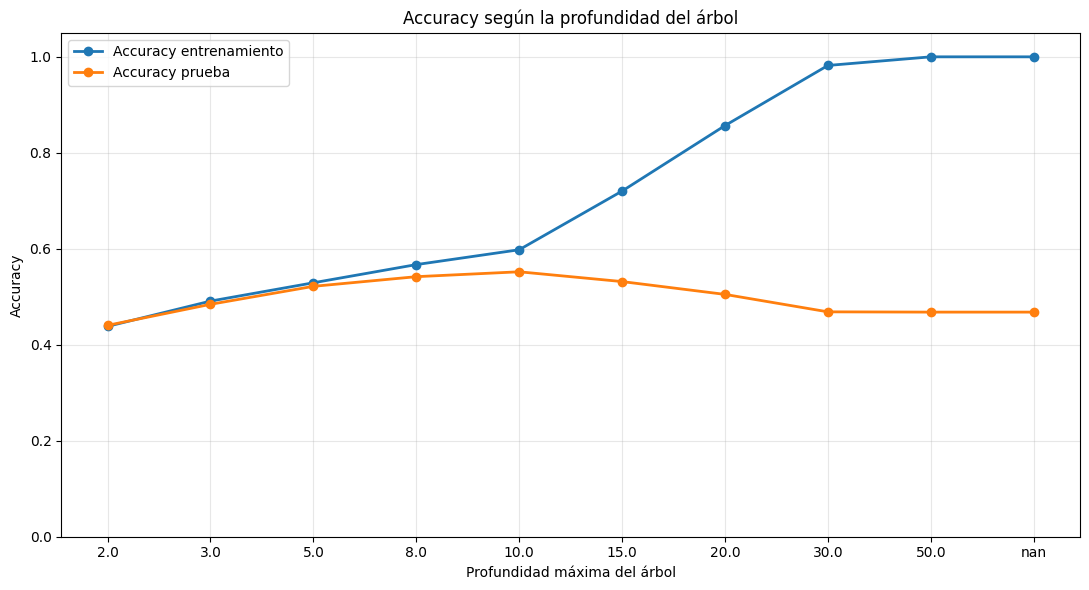

Mejor profundidad según Accuracy de prueba: 10.0
Accuracy de prueba: 0.5521

Brecha entre entrenamiento y prueba:


,Profundidad,Accuracy training,Accuracy test,Brecha_sobreajuste
0,2.0,0.4383,0.4405,-0.0022
1,3.0,0.4910,0.4843,0.0067
2,5.0,0.5292,0.5218,0.0074
3,8.0,0.5671,0.5419,0.0252
4,10.0,0.5980,0.5521,0.0459
5,15.0,0.7203,0.5317,0.1886
6,20.0,0.8567,0.5050,0.3518
7,30.0,0.9820,0.4686,0.5134
8,50.0,1.0000,0.4680,0.5320
9,nan,1.0000,0.4680,0.5320


In [62]:
# Preparar datos para la gráfica
tabla_grafica = tabla_profundidad.copy()

# Convertir None a una etiqueta para visualizarlo
tabla_grafica["Profundidad"] = tabla_grafica["max_depth"].apply(
    lambda x: "Sin límite" if x is None else str(x)
)

# Calcular la diferencia entre entrenamiento y prueba
tabla_grafica["Brecha_sobreajuste"] = (
    tabla_grafica["Accuracy training"] -
    tabla_grafica["Accuracy test"]
)

# Gráfica de accuracy según la profundidad
plt.figure(figsize=(11, 6))

plt.plot(
    tabla_grafica["Profundidad"],
    tabla_grafica["Accuracy training"],
    marker="o",
    linewidth=2,
    label="Accuracy entrenamiento"
)

plt.plot(
    tabla_grafica["Profundidad"],
    tabla_grafica["Accuracy test"],
    marker="o",
    linewidth=2,
    label="Accuracy prueba"
)

plt.title("Accuracy según la profundidad del árbol")
plt.xlabel("Profundidad máxima del árbol")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Mejor profundidad según el conjunto de prueba
mejor_fila = tabla_grafica.loc[
    tabla_grafica["Accuracy test"].idxmax()
]

print(
    f"Mejor profundidad según Accuracy de prueba: "
    f"{mejor_fila['Profundidad']}"
)
print(
    f"Accuracy de prueba: "
    f"{mejor_fila['Accuracy test']:.4f}"
)

# Mostrar la brecha entre entrenamiento y prueba
print("\nBrecha entre entrenamiento y prueba:")
display(
    tabla_grafica[
        ["Profundidad", "Accuracy training",
         "Accuracy test", "Brecha_sobreajuste"]
    ].round(4)
)

In [63]:
# Reemplaza la celda actual de la curva de complejidad

from joblib import Parallel, delayed
import os

R = 25
profundidades = range(1, 21)

def evaluar_semilla(semilla):
    X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
        X_clasificacion,
        y_clasificacion,
        test_size=0.20,
        random_state=semilla,
        stratify=y_clasificacion
    )

    X_train_r = agrupar_categorias_raras(
        X_train_r,
        ["Club", "Nationality"],
        minimo=10
    )

    X_test_r = agrupar_categorias_raras(
        X_test_r,
        ["Club", "Nationality"],
        minimo=10
    )

    resultados = []

    for profundidad in profundidades:
        pipeline = Pipeline([
            ("preprocesador", clone(preprocesador_completo)),
            ("modelo", DecisionTreeClassifier(
                max_depth=profundidad,
                random_state=2026
            ))
        ])

        pipeline.fit(X_train_r, y_train_r)

        resultados.append({
            "semilla": semilla,
            "max_depth": profundidad,
            "Accuracy training": pipeline.score(X_train_r, y_train_r),
            "Accuracy test": pipeline.score(X_test_r, y_test_r)
        })

    return resultados


# Usa todos los núcleos disponibles
resultados_paralelos = Parallel(
    n_jobs=-1,
    backend="loky",
    verbose=10,
    pre_dispatch="n_jobs"
)(
    delayed(evaluar_semilla)(semilla)
    for semilla in range(R)
)

resultados_repetidos = pd.DataFrame([
    resultado
    for grupo in resultados_paralelos
    for resultado in grupo
])

tabla_promedio = (
    resultados_repetidos
    .groupby("max_depth")
    .agg(
        Accuracy_training=("Accuracy training", "mean"),
        Accuracy_test=("Accuracy test", "mean"),
        desviacion_test=("Accuracy test", "std")
    )
    .reset_index()
)

tabla_promedio["Brecha_sobreajuste"] = (
    tabla_promedio["Accuracy_training"] -
    tabla_promedio["Accuracy_test"]
)

display(tabla_promedio.round(4))

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


KeyError: 'Club'

In [ ]:
mejor_fila = tabla_promedio.loc[
    tabla_promedio["Accuracy_test"].idxmax()
]

profundidad_optima = int(mejor_fila["max_depth"])

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    tabla_promedio["max_depth"],
    tabla_promedio["Accuracy_training"],
    "o-",
    linewidth=2,
    label="Accuracy entrenamiento"
)

ax.plot(
    tabla_promedio["max_depth"],
    tabla_promedio["Accuracy_test"],
    "s-",
    linewidth=2,
    label="Accuracy prueba promedio"
)

# Banda de variación entre particiones
ax.fill_between(
    tabla_promedio["max_depth"],
    tabla_promedio["Accuracy_test"] -
    tabla_promedio["desviacion_test"],
    tabla_promedio["Accuracy_test"] +
    tabla_promedio["desviacion_test"],
    alpha=0.15,
    label="Desviación estándar"
)

ax.axvline(
    profundidad_optima,
    color="red",
    linestyle="--",
    label=f"Profundidad óptima: {profundidad_optima}"
)

ax.set_title(
    f"Curva de complejidad del árbol ({R} particiones)"
)
ax.set_xlabel("Profundidad máxima del árbol")
ax.set_ylabel("Accuracy")
ax.set_xticks(list(profundidades))
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

print(
    f"Profundidad recomendada: {profundidad_optima}"
)
print(
    f"Accuracy promedio en prueba: "
    f"{mejor_fila['Accuracy_test']:.4f}"
)
print(
    f"Brecha de sobreajuste: "
    f"{mejor_fila['Brecha_sobreajuste']:.4f}"
)

In [ ]:
# Modelos KNN y Naive Bayes para predecir Position_Group

X_train_modelos = X_train.copy()
X_test_modelos = X_test.copy()

preprocesador_modelos = clone(preprocesador_completo).set_params(
    categoricas__onehot__sparse_output=False
)

modelos_comparacion = {
    "KNN": KNeighborsClassifier(
        n_neighbors=5,
        n_jobs=-1
    ),
    "Naive Bayes": GaussianNB()
}

resultados_modelos = []
predicciones_modelos = {}

for nombre, modelo in modelos_comparacion.items():
    pipeline_modelo = Pipeline([
        ("preprocesador", clone(preprocesador_modelos)),
        ("modelo", modelo)
    ])

    pipeline_modelo.fit(X_train_modelos, y_train)
    predicciones = pipeline_modelo.predict(X_test_modelos)

    predicciones_modelos[nombre] = predicciones

    resultados_modelos.append({
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test, predicciones),
        "Balanced Accuracy": balanced_accuracy_score(y_test, predicciones),
        "Precision macro": precision_score(
            y_test, predicciones, average="macro", zero_division=0
        ),
        "Recall macro": recall_score(
            y_test, predicciones, average="macro", zero_division=0
        ),
        "F1 macro": f1_score(
            y_test, predicciones, average="macro", zero_division=0
        ),
        "F1 weighted": f1_score(
            y_test, predicciones, average="weighted", zero_division=0
        )
    })

tabla_modelos = pd.DataFrame(resultados_modelos).sort_values(
    by="F1 macro",
    ascending=False
)

display(tabla_modelos.round(4))

for nombre, predicciones in predicciones_modelos.items():
    print(f"\n{'=' * 60}")
    print(nombre)
    print("=" * 60)
    print(classification_report(
        y_test,
        predicciones,
        zero_division=0
    ))

mejor_modelo = tabla_modelos.iloc[0]["Modelo"]
pred_mejor = predicciones_modelos[mejor_modelo]

print(f"\nMejor modelo según F1 macro: {mejor_modelo}")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_mejor,
    xticks_rotation=45,
    cmap="Blues",
    values_format="d"
)

plt.title(f"Matriz de confusión - {mejor_modelo}")
plt.tight_layout()
plt.show()

In [ ]:
# Verificación de rangos finales después del StandardScaler

preprocesador_entrenado = pipeline_modelo.named_steps["preprocesador"]
datos_transformados = preprocesador_entrenado.transform(X_train_modelos)
nombres_transformados = preprocesador_entrenado.get_feature_names_out()

if hasattr(datos_transformados, "toarray"):
    datos_transformados = datos_transformados.toarray()

indices_estandarizados = [
    indice
    for indice, nombre in enumerate(nombres_transformados)
    if nombre.startswith("numericas__") or nombre.startswith("ordinales__")
 ]

tabla_rangos_estandarizados = pd.DataFrame(
    datos_transformados[:, indices_estandarizados],
    columns=nombres_transformados[indices_estandarizados]
 ).agg(["min", "max", "mean", "std"]).T

print("Rangos finales de las columnas numéricas y ordinales estandarizadas:")
display(tabla_rangos_estandarizados.round(4))

print("\nComprobación de la estandarización:")
print(
    "Mayor diferencia absoluta respecto a media 0:",
    f"{tabla_rangos_estandarizados['mean'].abs().max():.6f}"
)
print(
    "Mayor diferencia absoluta respecto a desviación 1:",
    f"{(tabla_rangos_estandarizados['std'] - 1).abs().max():.6f}"
)

In [ ]:
# Comparación con magnitudes monetarias reducidas

columnas_monetarias = ["Value", "Wage", "Release Clause"]
columnas_faltantes = [
    columna for columna in columnas_monetarias
    if columna not in X_train_modelos.columns
 ]

if columnas_faltantes:
    raise KeyError(
        f"Faltan columnas monetarias en X_train_modelos: {columnas_faltantes}"
    )

# Copia independiente: no modifica df ni X_train_modelos
df_monetario_log = df.copy(deep=True)
for columna in columnas_monetarias:
    df_monetario_log[columna] = np.log10(
        1 + df_monetario_log[columna] / 1000
    ).clip(upper=6)

X_train_monetario_log = X_train_modelos.copy()
X_test_monetario_log = X_test_modelos.copy()

for columna in columnas_monetarias:
    X_train_monetario_log[columna] = np.log10(
        1 + X_train_monetario_log[columna] / 1000
    ).clip(upper=6)
    X_test_monetario_log[columna] = np.log10(
        1 + X_test_monetario_log[columna] / 1000
    ).clip(upper=6)

print("Rangos monetarios antes y después de la transformación:")
tabla_rangos_monetarios = pd.DataFrame({
    "Original_min": X_train_modelos[columnas_monetarias].min(),
    "Original_max": X_train_modelos[columnas_monetarias].max(),
    "Log_min": X_train_monetario_log[columnas_monetarias].min(),
    "Log_max": X_train_monetario_log[columnas_monetarias].max()
})
display(tabla_rangos_monetarios.round(4))

def evaluar_datos_clasificacion(nombre_datos, datos_train, datos_test):
    resultados = []
    for nombre_modelo, modelo_base in modelos_comparacion.items():
        pipeline_comparacion = Pipeline([
            ("preprocesador", clone(preprocesador_modelos)),
            ("modelo", clone(modelo_base))
        ])
        pipeline_comparacion.fit(datos_train, y_train)
        predicciones = pipeline_comparacion.predict(datos_test)

        resultados.append({
            "Datos": nombre_datos,
            "Modelo": nombre_modelo,
            "Accuracy": accuracy_score(y_test, predicciones),
            "Balanced Accuracy": balanced_accuracy_score(y_test, predicciones),
            "Precision macro": precision_score(
                y_test, predicciones, average="macro", zero_division=0
            ),
            "Recall macro": recall_score(
                y_test, predicciones, average="macro", zero_division=0
            ),
            "F1 macro": f1_score(
                y_test, predicciones, average="macro", zero_division=0
            ),
            "F1 weighted": f1_score(
                y_test, predicciones, average="weighted", zero_division=0
            )
        })
    return resultados

resultados_comparacion_monetaria = (
    evaluar_datos_clasificacion(
        "Original", X_train_modelos, X_test_modelos
    )
    + evaluar_datos_clasificacion(
        "Log10 miles de euros",
        X_train_monetario_log,
        X_test_monetario_log
    )
 )

tabla_comparacion_monetaria = pd.DataFrame(resultados_comparacion_monetaria)
tabla_comparacion_monetaria = tabla_comparacion_monetaria.sort_values(
    ["Modelo", "Datos"]
 )

print("Comparación de resultados:")
display(tabla_comparacion_monetaria.round(4))

tabla_diferencias_monetaria = (
    tabla_comparacion_monetaria
    .pivot(index="Modelo", columns="Datos", values=["Accuracy", "F1 macro"])
 )
tabla_diferencias_monetaria["Accuracy_delta_log_menos_original"] = (
    tabla_diferencias_monetaria["Accuracy"]["Log10 miles de euros"]
    - tabla_diferencias_monetaria["Accuracy"]["Original"]
 )
tabla_diferencias_monetaria["F1_macro_delta_log_menos_original"] = (
    tabla_diferencias_monetaria["F1 macro"]["Log10 miles de euros"]
    - tabla_diferencias_monetaria["F1 macro"]["Original"]
 )

print("Diferencia: transformación monetaria menos original")
display(
    tabla_diferencias_monetaria[
        [
            "Accuracy_delta_log_menos_original",
            "F1_macro_delta_log_menos_original"
        ]
    ].round(4)
 )

In [ ]:
# Máquinas de soporte vectorial para predecir Position_Group

from joblib import Parallel, delayed
from sklearn.svm import LinearSVC

# Se conservan todas las categorías, incluida la alta cardinalidad.
# OneHotEncoder disperso evita construir una matriz densa innecesariamente grande.
columnas_categoricas_svm = columnas_categoricas_modelo.copy()

preprocesador_svm = ColumnTransformer(
    transformers=[
        (
            "numericas",
            clone(preprocesador_completo.transformers[0][1]),
            columnas_numericas_modelo
        ),
        (
            "ordinales",
            clone(preprocesador_completo.transformers[1][1]),
            columnas_ordinales_modelo
        ),
        (
            "categoricas",
            clone(preprocesador_completo.transformers[2][1]).set_params(
                onehot__sparse_output=True
            ),
            columnas_categoricas_svm
        )
    ],
    remainder="drop"
 )

modelos_svm = {
    "SVM lineal": LinearSVC(
        C=1.0,
        tol=1e-3,
        max_iter=5000,
        random_state=2026
    )
}

def evaluar_svm(nombre_datos, datos_train, datos_test):
    resultados = []
    predicciones = {}

    for nombre_modelo, modelo_base in modelos_svm.items():
        pipeline_svm = Pipeline([
            ("preprocesador", clone(preprocesador_svm)),
            ("modelo", clone(modelo_base))
        ])

        pipeline_svm.fit(datos_train, y_train)
        prediccion = pipeline_svm.predict(datos_test)
        predicciones[nombre_modelo] = prediccion

        resultados.append({
            "Datos": nombre_datos,
            "Modelo": nombre_modelo,
            "Accuracy": accuracy_score(y_test, prediccion),
            "Balanced Accuracy": balanced_accuracy_score(y_test, prediccion),
            "Precision macro": precision_score(
                y_test, prediccion, average="macro", zero_division=0
            ),
            "Recall macro": recall_score(
                y_test, prediccion, average="macro", zero_division=0
            ),
            "F1 macro": f1_score(
                y_test, prediccion, average="macro", zero_division=0
            ),
            "F1 weighted": f1_score(
                y_test, prediccion, average="weighted", zero_division=0
            )
        })

    return resultados, predicciones

configuraciones_svm = [
    ("Original", X_train_modelos, X_test_modelos),
    (
        "Log10 miles de euros",
        X_train_monetario_log,
        X_test_monetario_log
    )
 ]

# LinearSVC no tiene n_jobs; se paralelizan los entrenamientos independientes.
resultados_svm_paralelos = Parallel(
    n_jobs=-1,
    backend="loky",
    verbose=10
 )(
    delayed(evaluar_svm)(nombre, datos_train, datos_test)
    for nombre, datos_train, datos_test in configuraciones_svm
 )

resultados_svm = [
    resultado
    for resultados, _ in resultados_svm_paralelos
    for resultado in resultados
 ]
predicciones_svm = {
    nombre_datos: predicciones
    for (nombre_datos, _, _), (_, predicciones)
    in zip(configuraciones_svm, resultados_svm_paralelos)
 }

tabla_svm = pd.DataFrame(resultados_svm).sort_values(
    ["Modelo", "Datos"]
 )

print("Resultados de SVM lineal usando Club y Nationality:")
display(tabla_svm.round(4))

print("Reporte de clasificación de SVM lineal con datos originales:")
for nombre_modelo, prediccion in predicciones_svm["Original"].items():
    print(f"\n{'=' * 60}")
    print(nombre_modelo)
    print("=" * 60)
    print(classification_report(
        y_test,
        prediccion,
        zero_division=0
    ))

tabla_modelos_original = tabla_modelos.copy()
tabla_modelos_original["Datos"] = "Original"
tabla_comparacion_modelos_original = pd.concat(
    [tabla_modelos_original,
     tabla_svm[tabla_svm["Datos"] == "Original"]],
    ignore_index=True
 ).sort_values(
    "F1 macro",
    ascending=False
 )

In [ ]:
# Comparación final incluyendo el árbol de decisión

predicciones_arbol = pipeline_arbol.predict(X_test)

fila_arbol = pd.DataFrame([{
    "Modelo": "Árbol de decisión",
    "Accuracy": accuracy_score(y_test, predicciones_arbol),
    "Balanced Accuracy": balanced_accuracy_score(
        y_test, predicciones_arbol
    ),
    "Precision macro": precision_score(
        y_test, predicciones_arbol, average="macro", zero_division=0
    ),
    "Recall macro": recall_score(
        y_test, predicciones_arbol, average="macro", zero_division=0
    ),
    "F1 macro": f1_score(
        y_test, predicciones_arbol, average="macro", zero_division=0
    ),
    "F1 weighted": f1_score(
        y_test, predicciones_arbol, average="weighted", zero_division=0
    ),
    "Datos": "Original"
}])

tabla_comparacion_final = pd.concat(
    [
        tabla_modelos_original,
        fila_arbol,
        tabla_svm[tabla_svm["Datos"] == "Original"]
    ],
    ignore_index=True
 ).sort_values(
    "F1 macro",
    ascending=False
 )

print("Comparación final de modelos con datos originales:")
display(tabla_comparacion_final.round(4))

print("Reporte de clasificación del árbol de decisión:")
print(classification_report(
    y_test,
    predicciones_arbol,
    zero_division=0
 ))

In [ ]:
# Evaluación sin Club ni Nationality

columnas_excluidas = ["Club", "Nationality"]
columnas_modelo_sin_club_nat = [
    columna for columna in columnas_modelo
    if columna not in columnas_excluidas
 ]

X_train_sin_club_nat = X_train_modelos[columnas_modelo_sin_club_nat].copy()
X_test_sin_club_nat = X_test_modelos[columnas_modelo_sin_club_nat].copy()

columnas_categoricas_sin_club_nat = [
    columna for columna in columnas_categoricas_modelo
    if columna not in columnas_excluidas
 ]

def crear_preprocesador_sin_club_nat(salida_densa):
    return ColumnTransformer(
        transformers=[
            (
                "numericas",
                clone(preprocesador_completo.transformers[0][1]),
                columnas_numericas_modelo
            ),
            (
                "ordinales",
                clone(preprocesador_completo.transformers[1][1]),
                columnas_ordinales_modelo
            ),
            (
                "categoricas",
                clone(preprocesador_completo.transformers[2][1]).set_params(
                    onehot__sparse_output=salida_densa
                ),
                columnas_categoricas_sin_club_nat
            )
        ],
        remainder="drop"
    )

preprocesador_sin_club_nat_denso = crear_preprocesador_sin_club_nat(
    salida_densa=False
 )
preprocesador_sin_club_nat_svm = crear_preprocesador_sin_club_nat(
    salida_densa=True
 )

modelos_sin_club_nat = {
    "KNN": (
        KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
        preprocesador_sin_club_nat_denso
    ),
    "Naive Bayes": (
        GaussianNB(),
        preprocesador_sin_club_nat_denso
    ),
    "SVM lineal": (
        LinearSVC(
            C=1.0,
            tol=1e-3,
            max_iter=5000,
            random_state=2026
        ),
        preprocesador_sin_club_nat_svm
    ),
    "Árbol de decisión": (
        DecisionTreeClassifier(
            max_depth=5,
            random_state=2026
        ),
        preprocesador_sin_club_nat_denso
    )
}

resultados_sin_club_nat = []
predicciones_sin_club_nat = {}

for nombre_modelo, (modelo_base, preprocesador_base) in modelos_sin_club_nat.items():
    pipeline_sin_club_nat = Pipeline([
        ("preprocesador", clone(preprocesador_base)),
        ("modelo", clone(modelo_base))
    ])

    pipeline_sin_club_nat.fit(
        X_train_sin_club_nat,
        y_train
    )
    prediccion = pipeline_sin_club_nat.predict(X_test_sin_club_nat)
    predicciones_sin_club_nat[nombre_modelo] = prediccion

    resultados_sin_club_nat.append({
        "Modelo": nombre_modelo,
        "Accuracy": accuracy_score(y_test, prediccion),
        "Balanced Accuracy": balanced_accuracy_score(
            y_test, prediccion
        ),
        "Precision macro": precision_score(
            y_test, prediccion, average="macro", zero_division=0
        ),
        "Recall macro": recall_score(
            y_test, prediccion, average="macro", zero_division=0
        ),
        "F1 macro": f1_score(
            y_test, prediccion, average="macro", zero_division=0
        ),
        "F1 weighted": f1_score(
            y_test, prediccion, average="weighted", zero_division=0
        ),
        "Datos": "Sin Club/Nationality"
    })

tabla_sin_club_nat = pd.DataFrame(resultados_sin_club_nat)
tabla_comparacion_club_nat = pd.concat(
    [
        tabla_comparacion_final,
        tabla_sin_club_nat
    ],
    ignore_index=True
 )

print("Resultados sin Club ni Nationality:")
display(tabla_sin_club_nat.round(4))

print("Comparación completa:")
display(
    tabla_comparacion_club_nat.sort_values(
        ["Modelo", "Datos"]
    ).round(4)
 )

tabla_diferencias_club_nat = (
    tabla_comparacion_club_nat
    .pivot(index="Modelo", columns="Datos", values=[
        "Accuracy",
        "Balanced Accuracy",
        "F1 macro"
    ])
 )

for metrica in ["Accuracy", "Balanced Accuracy", "F1 macro"]:
    tabla_diferencias_club_nat[
        f"Delta_{metrica}_sin_menos_con"
    ] = (
        tabla_diferencias_club_nat[metrica]["Sin Club/Nationality"]
        - tabla_diferencias_club_nat[metrica]["Original"]
    )

print("Efecto de excluir Club y Nationality:")
display(
    tabla_diferencias_club_nat[
        [
            "Delta_Accuracy_sin_menos_con",
            "Delta_Balanced Accuracy_sin_menos_con",
            "Delta_F1 macro_sin_menos_con"
        ]
    ].round(4)
 )

In [ ]:
# Selección de semillas e hiperparámetros por modelo

from joblib import Parallel, delayed
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.svm import LinearSVC

# Este conjunto puede modificarse para repetir la búsqueda con otras semillas.
semillas_experimento = [2026, 7, 17, 42, 100]

configuraciones_por_modelo = {
    "KNN": [
        ("n_neighbors", 3),
        ("n_neighbors", 5),
        ("n_neighbors", 9)
    ],
    "Naive Bayes": [
        ("var_smoothing", 1e-9),
        ("var_smoothing", 1e-8),
        ("var_smoothing", 1e-7)
    ],
    "SVM lineal": [
        ("C", 0.01),
        ("C", 0.1),
        ("C", 1.0)
    ],
    "Árbol de decisión": [
        ("max_depth", 3),
        ("max_depth", 5),
        ("max_depth", 8)
    ]
}

def crear_pipeline_validacion(nombre_modelo, valor_hiperparametro):
    if nombre_modelo == "KNN":
        modelo = KNeighborsClassifier(
            n_neighbors=int(valor_hiperparametro),
            n_jobs=-1
        )
        preprocesador = clone(preprocesador_modelos)
    elif nombre_modelo == "Naive Bayes":
        modelo = GaussianNB(
            var_smoothing=float(valor_hiperparametro)
        )
        preprocesador = clone(preprocesador_modelos)
    elif nombre_modelo == "SVM lineal":
        modelo = LinearSVC(
            C=float(valor_hiperparametro),
            tol=1e-3,
            max_iter=5000,
            random_state=2026
        )
        preprocesador = clone(preprocesador_svm)
    elif nombre_modelo == "Árbol de decisión":
        modelo = DecisionTreeClassifier(
            max_depth=int(valor_hiperparametro),
            random_state=2026
        )
        preprocesador = clone(preprocesador_completo)
    else:
        raise ValueError(f"Modelo no reconocido: {nombre_modelo}")

    return Pipeline([
        ("preprocesador", preprocesador),
        ("modelo", modelo)
    ])

def evaluar_configuracion_semilla(semilla, nombre_modelo, nombre_hiperparametro, valor):
    X_train_semilla, X_test_semilla, y_train_semilla, y_test_semilla = train_test_split(
        X_clasificacion,
        y_clasificacion,
        test_size=0.20,
        random_state=semilla,
        stratify=y_clasificacion
    )

    pipeline_validacion = crear_pipeline_validacion(
        nombre_modelo,
        valor
    )
    pipeline_validacion.fit(
        X_train_semilla,
        y_train_semilla
    )
    prediccion = pipeline_validacion.predict(X_test_semilla)

    return {
        "Semilla": semilla,
        "Modelo": nombre_modelo,
        "Hiperparametro": nombre_hiperparametro,
        "Valor": valor,
        "Accuracy": accuracy_score(y_test_semilla, prediccion),
        "Balanced Accuracy": balanced_accuracy_score(
            y_test_semilla, prediccion
        ),
        "Precision macro": precision_score(
            y_test_semilla,
            prediccion,
            average="macro",
            zero_division=0
        ),
        "Recall macro": recall_score(
            y_test_semilla,
            prediccion,
            average="macro",
            zero_division=0
        ),
        "F1 macro": f1_score(
            y_test_semilla,
            prediccion,
            average="macro",
            zero_division=0
        )
    }

tareas_semillas = [
    (semilla, nombre_modelo, nombre_hiperparametro, valor)
    for semilla in semillas_experimento
    for nombre_modelo, configuraciones in configuraciones_por_modelo.items()
    for nombre_hiperparametro, valor in configuraciones
 ]

resultados_semillas = Parallel(
    n_jobs=-1,
    backend="loky",
    verbose=10
 )(
    delayed(evaluar_configuracion_semilla)(
        semilla,
        nombre_modelo,
        nombre_hiperparametro,
        valor
    )
    for semilla, nombre_modelo, nombre_hiperparametro, valor in tareas_semillas
 )

tabla_semillas = pd.DataFrame(resultados_semillas)
tabla_semillas = tabla_semillas.sort_values(
    ["Modelo", "Accuracy", "F1 macro"],
    ascending=[True, False, False]
 )

print("Resultados de semillas e hiperparámetros:")
display(tabla_semillas.round(4))

mejores_filas_semillas = (
    tabla_semillas
    .sort_values(
        ["Modelo", "Accuracy", "F1 macro"],
        ascending=[True, False, False]
    )
    .groupby("Modelo", as_index=False)
    .first()
 )

print("Mejor semilla y configuración por modelo según Accuracy:")
display(mejores_filas_semillas.round(4))

configuraciones_elegidas = {
    fila["Modelo"]: fila["Valor"]
    for _, fila in mejores_filas_semillas.iterrows()
}

print("Configuraciones que pasarán a la validación cruzada:")
for nombre_modelo, valor in configuraciones_elegidas.items():
    nombre_hiperparametro = mejores_filas_semillas.loc[
        mejores_filas_semillas["Modelo"] == nombre_modelo,
        "Hiperparametro"
    ].iloc[0]
    print(f"{nombre_modelo}: {nombre_hiperparametro}={valor}")

In [ ]:
# Validación cruzada estratificada con las configuraciones elegidas

cv_estratificada = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=2026
 )

scoring_cv = {
    "Accuracy": "accuracy",
    "Balanced Accuracy": "balanced_accuracy",
    "Precision macro": "precision_macro",
    "Recall macro": "recall_macro",
    "F1 macro": "f1_macro"
}

resultados_cv = []
resultados_folds_cv = []

for nombre_modelo, valor_hiperparametro in configuraciones_elegidas.items():
    pipeline_cv = crear_pipeline_validacion(
        nombre_modelo,
        valor_hiperparametro
    )

    # n_jobs=1 evita duplicar matrices densas grandes en memoria.
    scores_cv = cross_validate(
        pipeline_cv,
        X_clasificacion,
        y_clasificacion,
        cv=cv_estratificada,
        scoring=scoring_cv,
        n_jobs=1
    )

    fila_resumen = {
        "Modelo": nombre_modelo,
        "Hiperparametro": valor_hiperparametro
    }

    for metrica in scoring_cv:
        valores_metrica = scores_cv[f"test_{metrica}"]
        fila_resumen[f"{metrica} media"] = valores_metrica.mean()
        fila_resumen[f"{metrica} desviacion"] = valores_metrica.std()

        for fold, valor in enumerate(valores_metrica, start=1):
            resultados_folds_cv.append({
                "Modelo": nombre_modelo,
                "Fold": fold,
                "Metrica": metrica,
                "Valor": valor
            })

    resultados_cv.append(fila_resumen)

tabla_cv = pd.DataFrame(resultados_cv)
tabla_folds_cv = pd.DataFrame(resultados_folds_cv)

print("Resultados de validación cruzada estratificada:")
display(tabla_cv.round(4))

print("Resultados por fold:")
display(
    tabla_folds_cv.pivot_table(
        index=["Fold", "Modelo"],
        columns="Metrica",
        values="Valor"
    ).round(4)
 )

# Gráficas de media y desviación estándar
metricas_grafica = [
    "Accuracy",
    "Balanced Accuracy",
    "Precision macro",
    "Recall macro",
    "F1 macro"
 ]

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.ravel()

for indice, metrica in enumerate(metricas_grafica):
    ax = axes[indice]
    medias = tabla_cv[f"{metrica} media"]
    desviaciones = tabla_cv[f"{metrica} desviacion"]

    ax.bar(
        tabla_cv["Modelo"],
        medias,
        yerr=desviaciones,
        capsize=5,
        color="#2c7fb8"
    )
    ax.set_title(f"{metrica}: media +/- desviación")
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=35)
    ax.grid(axis="y", alpha=0.3)

# Ocultar el sexto eje sobrante
axes[-1].axis("off")
fig.suptitle("Comparación de modelos mediante validación cruzada", fontsize=16)
plt.tight_layout()
plt.show()

# Regla principal: Accuracy; desempate con F1 macro
tabla_cv_ordenada = tabla_cv.sort_values(
    ["Accuracy media", "F1 macro media"],
    ascending=False
 )

mejor_modelo_cv = tabla_cv_ordenada.iloc[0]
mejor_f1_cv = tabla_cv.sort_values(
    "F1 macro media",
    ascending=False
 ).iloc[0]

print("Modelo recomendado según Accuracy media y F1 macro como desempate:")
print(
    f"{mejor_modelo_cv['Modelo']} "
    f"(Accuracy = {mejor_modelo_cv['Accuracy media']:.4f} +/- "
    f"{mejor_modelo_cv['Accuracy desviacion']:.4f})"
 )

print("Modelo con mayor F1 macro medio:")
print(
    f"{mejor_f1_cv['Modelo']} "
    f"(F1 macro = {mejor_f1_cv['F1 macro media']:.4f} +/- "
    f"{mejor_f1_cv['F1 macro desviacion']:.4f})"
 )

In [ ]:
# Tabla final para el informe

columnas_semilla = [
    "Modelo",
    "Semilla",
    "Hiperparametro",
    "Valor",
    "Accuracy",
    "Balanced Accuracy",
    "F1 macro"
 ]

tabla_final_resultados = mejores_filas_semillas[columnas_semilla].merge(
    tabla_cv[
        [
            "Modelo",
            "Accuracy media",
            "Accuracy desviacion",
            "Balanced Accuracy media",
            "Balanced Accuracy desviacion",
            "Precision macro media",
            "Precision macro desviacion",
            "Recall macro media",
            "Recall macro desviacion",
            "F1 macro media",
            "F1 macro desviacion"
        ]
    ],
    on="Modelo",
    how="left"
 )

def formato_media_desviacion(fila, metrica):
    return (
        f"{fila[f'{metrica} media']:.4f} +/- "
        f"{fila[f'{metrica} desviacion']:.4f}"
    )

for metrica in [
    "Accuracy",
    "Balanced Accuracy",
    "Precision macro",
    "Recall macro",
    "F1 macro"
 ]:
    tabla_final_resultados[f"{metrica} CV"] = tabla_final_resultados.apply(
        lambda fila: formato_media_desviacion(fila, metrica),
        axis=1
    )

tabla_final_resultados["Configuracion"] = (
    tabla_final_resultados["Hiperparametro"].astype(str)
    + "="
    + tabla_final_resultados["Valor"].astype(str)
 )

tabla_final_resultados = tabla_final_resultados[
    [
        "Modelo",
        "Semilla",
        "Configuracion",
        "Accuracy",
        "Balanced Accuracy",
        "F1 macro",
        "Accuracy CV",
        "Balanced Accuracy CV",
        "Precision macro CV",
        "Recall macro CV",
        "F1 macro CV"
    ]
 ].sort_values(
    ["Accuracy CV", "F1 macro CV"],
    ascending=False
 )

print("Tabla final de comparación y validación cruzada:")
display(tabla_final_resultados)

print(
    f"\nModelo recomendado: {mejor_modelo_cv['Modelo']}. "
    f"Accuracy CV = {mejor_modelo_cv['Accuracy media']:.4f} +/- "
    f"{mejor_modelo_cv['Accuracy desviacion']:.4f}; "
    f"F1 macro CV = {mejor_modelo_cv['F1 macro media']:.4f} +/- "
    f"{mejor_modelo_cv['F1 macro desviacion']:.4f}."
 )